In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from bs4 import BeautifulSoup, NavigableString, Tag
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import requests
import threading

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from indoNLP.preprocessing import replace_slang
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import spacy

from tqdm import tqdm
import re
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
kode_saham = "BUMI"
kategori_saham = ['Pertambangan', 'Mineral', 'Energy', 'Energi', 'Sumber Daya Alam', 'SDA', 'migas', 'gas']
media_keywords = ['tribunnews', 'kompas', 'cnn', 'republika', 'tempo', 'detik', 'liputan6', 'okezone', 'tribunnewscom', 'kompascom', 'cnncom', 'republikacom', 'tempocom', 'detikcom', 'liputan6com', 'okezonecom', 'bisniscom']
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}
start = "2018-01-01"
end = datetime.now().strftime("%Y-%m-%d")
max_retries = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def init_driver():
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ['enable-automation'])
    options.add_experimental_option("useAutomationExtension", False)
    options.add_argument("--disable-notifications")

    driver = webdriver.Chrome(options=options)
    return driver

def load_page(driver, element, max_retries = 10):
    for _ in range(max_retries):
        try:
            WebDriverWait(driver, 60).until(
                EC.presence_of_element_located((By.CSS_SELECTOR, element))
            )
            break
        except TimeoutException:
            print("Refresh driver")
            driver.refresh()
            time.sleep(3)
    else:
        print("Gagal memuat halaman")
    
    time.sleep(2)
    html = driver.page_source
    
    return html

## Load Data Saham

In [10]:
df = yf.download(kode_saham+'.JK', start=start, end=end)
df.columns = df.columns.droplevel(1)
df.columns.name = None
df = df.reset_index()
df.to_csv(f"{kode_saham}.csv")
df

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2018-01-01,270.0,270.0,270.0,270.0,0
1,2018-01-02,268.0,274.0,262.0,272.0,253027500
2,2018-01-03,274.0,280.0,268.0,270.0,383260100
3,2018-01-04,276.0,280.0,270.0,276.0,256846300
4,2018-01-05,294.0,300.0,276.0,278.0,1263758100
...,...,...,...,...,...,...
2064,2026-06-04,150.0,153.0,137.0,149.0,4978373200
2065,2026-06-05,139.0,153.0,139.0,152.0,3062335900
2066,2026-06-08,130.0,139.0,126.0,132.0,4621181600
2067,2026-06-09,146.0,148.0,129.0,130.0,5625440400


## Load Data IHSG

In [9]:
df_ihsg = yf.download('^JKSE', start=start, end=end)
df_ihsg.columns = df_ihsg.columns.droplevel(1)
df_ihsg.columns.name = None
df_ihsg = df_ihsg.reset_index()
df_ihsg.to_csv(f"IHSG.csv")

[*********************100%***********************]  1 of 1 completed


## Load Data Berita

In [6]:
news_national_keys = {'mata uang', 'kurs', 'rupiah', 'suku bunga', 'sbn', 'bi rate', 'bank indonesia', 'inflasi', 'BI 7-day RR', 'cadangan devisa'}
news_international_keys = {'dollar', 'dolar', 'fed', 'feds', 'the fed', 'the feds', 'USA', 'United State America', 'Amerika Serikat', 'Presiden Amerika Serikat', 'Federal Reserve', 'FOMC', 'US Dollar', 'USD', 'greenback', 'washington', 'white house', 'gedung putih', 'ECB', 'Bank of England', 'BOJ', 'Trump', 'MSCI', 'FTSE'}
company_international_keys = {kode_saham} | set(kategori_saham)

news_national_key_lower = [news_national_key.lower() for news_national_key in news_national_keys]
news_international_key_lower = [news_international_key.lower() for news_international_key in news_international_keys]
company_international_key_lower = [company_international_key.lower() for company_international_key in company_international_keys]

national_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in news_national_key_lower) + r')\b', re.IGNORECASE)
international_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in news_international_key_lower) + r')\b', re.IGNORECASE)
company_pattern = re.compile(r'\b(?:' + '|'.join(re.escape(k) for k in company_international_key_lower) + r')\b', re.IGNORECASE)

In [7]:
try:
    news_list = pd.read_csv('news.csv')
except FileNotFoundError:
    print("File news.csv not found")
    news_list = pd.DataFrame()
    newest_date = None
else:
    if 'Unnamed: 0' in news_list.columns:
        news_list.drop('Unnamed: 0', axis=1, inplace=True)
    
    if 'date' in news_list.columns:
        # news_list['date'] = pd.to_datetime(news_list['date'], errors='coerce')
        newest_date = news_list['date'].max()

        if pd.isna(newest_date):
            newest_date = None
        else:
            newest_date = datetime.strptime(newest_date, "%Y-%m-%d")    
    else:
        newest_date = None

# news_list
newest_date

datetime.datetime(2026, 6, 10, 0, 0)

In [8]:
def element_to_formatted_text(element):
    if isinstance(element, NavigableString):
        text = element.strip()
        return text if text else ''
    
    if not isinstance(element, Tag):
        return ''
    
    if element.name in ('ul', 'ol'):
        items = []
        for li in element.find_all('li', recursive=False):
            li_text = ' '.join(
                element_to_formatted_text(child) for child in li.children
            ).strip()
            if li_text:
                items.append(li_text)
        return ', '.join(items)
    
    parts = []
    for child in element.children:
        child_text = element_to_formatted_text(child)
        if child_text:
            parts.append(child_text)
    
    return ' '.join(parts)

### Detik.com

In [9]:
def loadDetikNews(loadedNews):
    url = "https://finance.detik.com/indeks?page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find_all('a', class_="pagination__item")

        for pagination in paginations:
            text = pagination.text.strip()
            try:
                page = int(text)
                if total_page < page:
                    total_page = page
            except ValueError:
                continue
        
        
        news = []
        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break
            
            if i != 0:
                url = f"https://finance.detik.com/indeks?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            links = soup.find_all('a', class_="media__link")
            
            for link in links:
                text = link.text.strip()
                parent = link.parent
                date_div = parent.find_next_sibling(class_="media__date")

                if not date_div:
                    continue
                
                publish_date = date_div.text.strip()
                template_date_word = re.compile(r'(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    publish_date = datetime.today().strftime("%Y-%m-%d")
                else:
                    template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    
                    if match:
                        hari, bulan_str, tahun = match.groups()
                        publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                    else:
                        continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue
                
                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break

                if not link.get('href') or "finance.detik.com" not in link.get('href'):
                    continue
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": link.get('href'),
                        "title": link.text.strip(),
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents = soup.find_all('p')
            for content in contents:
                if "para_caption" not in content.get("class", []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")               
    return news

### CNN Indonesia

In [10]:
def loadCNNIndonesiaNews(loadedNews):
    url = "https://www.cnnindonesia.com/ekonomi/indeks/5?page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find_all('a', attrs={'dtr-evt': 'halaman'})

        for pagination in paginations:
            text = pagination.text.strip()
            try:
                page = int(text)
                if total_page < page:
                    total_page = page
            except ValueError:
                continue
        
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break   

            if i != 0:
                url = f"https://www.cnnindonesia.com/ekonomi/indeks/5?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            articles = soup.find_all('article', class_='flex-grow')
            if not articles:
                continue

            for article in articles:
                link = article.find('a', attrs={'aria-label': 'link description'})
                cleaned_contents = [child for child in link.contents if not isinstance(child, str)]
                if len(cleaned_contents) >= 2:
                    second_child_a = cleaned_contents[1]
                    cleaned_contents = [child for child in second_child_a.contents if not isinstance(child, str)]
                    if len(cleaned_contents) < 2:
                        continue
                    
                    text = cleaned_contents[0].text.strip()
                    second_child_second_child_a = cleaned_contents[1]
                    cleaned_contents = [child for child in second_child_second_child_a.contents if not isinstance(child, str)]
                    if len(cleaned_contents) < 2:
                        continue

                    date_div = cleaned_contents[1]
                    if not date_div:
                        continue
                    
                    publish_date = date_div.text.strip()
                    template_date_word = re.compile(r'\s*(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    if match:
                        publish_date = datetime.today()
                        nominal, type_data = match.groups()
                        nominal = int(nominal)
                        if type_data == "hari":
                            publish_date -= timedelta(days=nominal)
                        elif type_data == "minggu":
                            publish_date -= timedelta(weeks=nominal)
                        elif type_data == "bulan":
                            publish_date -= relativedelta(months=nominal)
                        
                        publish_date = publish_date.strftime("%Y-%m-%d")
                    else:
                        template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})', re.IGNORECASE)
                        match = template_date_word.search(publish_date)
                        
                        if match:
                            hari, bulan_str, tahun = match.groups()
                            publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                        else:
                            continue
                    
                    start_date = datetime.strptime(start, "%Y-%m-%d")
                    publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                    if publish_date_datetime_format < start_date:
                        continue

                    if not text or text in [n['title'] for n in news]:
                        continue

                    if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                        loaded_all = True
                        break
                    
                    if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                        news.append({
                            "link": link.get('href'),
                            "title": text,
                            "date": publish_date,
                            "content": ""
                        })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents = soup.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")              
    return news

### Bisnis.com

In [11]:
bisnis_dot_com_category = [5, 43, 194]
def loadBisnisDotCom(category, loadedNews):
    url = f"https://bisnis.com/index?categoryId={category}&page=1"
    total_page = 1
    bulan = {
        "Jan": "01",
        "Feb": "02",
        "Mar": "03",
        "Apr": "04",
        "Mei": "05",
        "Jun": "06",
        "Jul": "07",
        "Agu": "08",
        "Sep": "09",
        "Okt": "10",
        "Nov": "11",
        "Des": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        paginations = soup.find('p', class_="pagingLabel")
        template_pagination_label = re.compile(r'dari\s+(\d+)\s+halaman', re.IGNORECASE)
        match = template_pagination_label.search(paginations.text.strip())
        if not match:
            raise ValueError("Pagination label not found")
        
        total_page = int(match.group(1))
        
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break

            if i != 0:
                url = f"https://bisnis.com/index?categoryId={category}&page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            links = soup.find_all('div', class_="artContent")
            if not links:
                continue
            
            for link in links:
                link_element = link.find('a', class_="artLink")
                if not link_element:
                    continue

                base_url = link_element.get('href')

                title_element = link_element.find(class_="artTitle")
                date_element = link_element.find(class_="artDate")
                if not title_element or not date_element:
                    continue

                text = title_element.text.strip()
                publish_date = date_element.text.strip()
                template_date_word = re.compile(r'(\d+)\s+(\w+)\s+yang\s+lalu', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    publish_date = datetime.today().strftime("%Y-%m-%d")
                else:
                    template_date_word = re.compile(r'(\d{1,2})\s+(\w{3})\s+(\d{4})(?:\s*\|\s*(\d+):(\d+)\s+WIB)?', re.IGNORECASE)
                    match = template_date_word.search(publish_date)
                    
                    if match:
                        hari, bulan_str, tahun, _, _ = match.groups()
                        publish_date = f"{tahun}-{bulan[bulan_str]}-{hari.zfill(2)}"
                    else:
                        continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue

                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": base_url,
                        "title": text,
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')

            articles_element = soup.find('article', class_="detailsContent")
            if not articles_element:
                continue

            contents = articles_element.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")                
    return news

### Tribun.com

In [12]:
tribun_news_business_category = ["", "mikro", "investasi", "transportasi", "infrastruktur", "insight", "properti", "makro", "energi", "finansial"]
def loadTribunNews(category, loadedNews):
    url = f"https://tribunnews.com/index-news/bisnis/{category}?page=1"
    total_page = 1
    bulan = {
        "Januari": "01",
        "Februari": "02",
        "Maret": "03",
        "April": "04",
        "Mei": "05",
        "Juni": "06",
        "Juli": "07",
        "Agustus": "08",
        "September": "09",
        "Oktober": "10",
        "November": "11",
        "Desember": "12"
    }

    session = requests.Session()
    session.headers.update(headers)
    response = session.get(url)

    try:
        html = response.text
        soup = BeautifulSoup(html, 'html.parser')
        
        pagination_links = soup.find_all('a', attrs={'data-ci-pagination-page': True})
        if not pagination_links:
            raise ValueError("Tidak ada link pagination")
        total_page = max(int(link['data-ci-pagination-page']) for link in pagination_links)
        news = []

        loaded_all = False
        for i in range(total_page):
            if loaded_all:
                break

            if i != 0:
                url = f"https://tribunnews.com/index-news/bisnis/{category}?page={i+1}"
                response = session.get(url)
                html = response.text
                soup = BeautifulSoup(html, 'html.parser')

            news_list_container = soup.find("ul", class_="lsi")
            if not news_list_container:
                continue

            links = news_list_container.find_all('li')
            
            for link in links:
                link_element = link.find('h3')
                date_div = link.find('time')
                if not link_element or not date_div:
                    continue

                text_element = link_element.find('a')

                if not text_element:
                    continue
                
                base_url = text_element.get('href')
                text = text_element.get('title')
                publish_date = date_div.text.strip()

                template_date_word = re.compile(r'(?:\w+,\s*)?(\d{1,2})\s+(\w+)\s+(\d{4})\s+(\d{2}):(\d{2})\s+WIB', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    tanggal, bulan_str, tahun, _, _ = match.groups()
                    publish_date = f"{tahun}-{bulan[bulan_str]}-{tanggal.zfill(2)}"
                else:
                    continue
                
                start_date = datetime.strptime(start, "%Y-%m-%d")
                publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                if publish_date_datetime_format < start_date:
                    continue

                if not text or text in [n['title'] for n in news]:
                    continue

                if loadedNews is not None and (text in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                    loaded_all = True
                    break
                
                if(national_pattern.search(text) or international_pattern.search(text) or company_pattern.search(text)):
                    news.append({
                        "link": base_url,
                        "title": text,
                        "date": publish_date,
                        "content": ""
                    })
            
        for n in range(len(news)):
            response = session.get(news[n]["link"])
            html = response.text
            soup = BeautifulSoup(html, 'html.parser')
            contents_element = soup.find(class_="side-article")
            if not contents_element:
                continue
            contents = contents_element.find_all('p')
            for content in contents:
                if not content.get('class', []):
                    news[n] = {
                        "title": news[n]["title"],
                        "content": f"""{news[n]["content"]}
                        {content.text.strip()}""",
                        "link": news[n]["link"],
                        "date": news[n]["date"]
                    }
    finally:
        print("")                
    return news

### IDX

In [13]:
def loadIDXNews(loadedNews):
    bulan = {
        "Januari": "01",
        "Februari": "02",
        "Maret": "03",
        "April": "04",
        "Mei": "05",
        "Juni": "06",
        "Juli": "07",
        "Agustus": "08",
        "September": "09",
        "Oktober": "10",
        "November": "11",
        "Desember": "12"
    }

    url = "https://www.idx.co.id"
    requestUrl = url+"/id/berita/berita/?p=1"

    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_experimental_option("excludeSwitches", ['enable-automation'])
    options.add_experimental_option("useAutomationExtension", False)

    driver = webdriver.Chrome(options=options)
    driver.get(requestUrl)

    try:
        for _ in range(max_retries):
            try:
                WebDriverWait(driver, 60).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, "a.card-title"))
                )
                break
            except TimeoutException:
                driver.refresh()
                time.sleep(3)
        else:
            print("Gagal memuat halaman")
        
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)
        html = driver.page_source 

        soup = BeautifulSoup(html, 'html.parser')

        pages = soup.find_all('li')
        links = soup.find_all('a', class_="card-title")

        len_page = 0
        page_element_clue = re.compile(r'dari\s+(\d+)', re.IGNORECASE)
        news = []

        for page in pages:
            text = page.text.strip()
            match = page_element_clue.search(text)
            if match:
                num_text = match.group(1)
                len_page = int(num_text)
        
        loaded_all = False
        for i in range(len_page):
            if loaded_all:
                break

            if i != 0:
                url = "https://www.idx.co.id"
                requestUrl = url+f"/id/berita/berita/?p={i+1}"
                driver.get(requestUrl)
                for _ in range(max_retries):
                    try:
                        WebDriverWait(driver, 60).until(
                            EC.presence_of_element_located((By.CSS_SELECTOR, "a.card-title"))
                        )
                        break
                    except TimeoutException:
                        driver.refresh()
                        time.sleep(3)
                else:
                    print("Gagal memuat halaman")
                    continue
                    
                driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
                time.sleep(2)
                html = driver.page_source
                
                soup = BeautifulSoup(html, 'html.parser')
                links = soup.find_all('a', class_="card-title")
            
            for link in links:
                title = link.text.strip()

                date_div = link.find_previous_sibling("small")
                publish_date = date_div.text.strip()
                template_date_word = re.compile(r'(\d{2})\s+(\w+)\s+(\d{4})', re.IGNORECASE)
                match = template_date_word.search(publish_date)
                if match:
                    date, month, year = match.groups()
                    publish_date = f"{year}-{bulan[month]}-{date.zfill(2)}"

                    start_date = datetime.strptime(start, "%Y-%m-%d")
                    publish_date_datetime_format = datetime.strptime(publish_date, "%Y-%m-%d")

                    if publish_date_datetime_format < start_date:
                        continue
                    
                    if title in [n['title'] for n in news]:
                        continue

                    if loadedNews is not None and (title in loadedNews['title'].values or (newest_date is not None and publish_date_datetime_format < newest_date)):
                        loaded_all = True
                        break
           
                    news.append({
                        "link": link.get('href'),
                        "title": title,
                        "content": "",
                        "date": publish_date
                    })
        
        for n in range(len(news)):
            url = "https://www.idx.co.id"
            requestUrl = url+news[n]['link']

            driver.get(requestUrl)
            
            for attempt in range(max_retries):
                try:
                    WebDriverWait(driver, 60).until(
                        EC.presence_of_element_located((By.CSS_SELECTOR, "article.clearfix"))
                    )
                    break
                except TimeoutException:
                    driver.refresh()
                    time.sleep(3)
            else:
                print("Gagal memuat halaman")
                continue

            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(2)
            html = driver.page_source
            soup = BeautifulSoup(html, 'html.parser')
            article = soup.find('article')
            contents = article.children
            
            for content in contents:
                if isinstance(content, Tag):
                    text = element_to_formatted_text(content)
                    if text:      
                        news[n] = {
                            "title": news[n]["title"],
                            "content": f"""{news[n]["content"]}
                            {content.text.strip()}""", 
                            "date": news[n]["date"]
                        } 
    finally:
        driver.quit()
    return news

### CNBC

### CNN Bussiness

### Financial Times

### Bloomberg

### Load all data

In [14]:
new_news_list = []
with ThreadPoolExecutor() as executor:
    futures = []
    futures.append(executor.submit(loadDetikNews, news_list))
    futures.append(executor.submit(loadCNNIndonesiaNews, news_list))
    for category in bisnis_dot_com_category:
        futures.append(executor.submit(loadBisnisDotCom, category, news_list))
    for category in tribun_news_business_category:
        futures.append(executor.submit(loadTribunNews, category, news_list))
    futures.append(executor.submit(loadIDXNews, news_list))
    for f in futures:
        new_news_list.extend(f.result())
    

new_news_list = sorted(new_news_list, key=lambda x: x['date'])

In [15]:
new_news_list = pd.DataFrame(new_news_list)
news_list = pd.concat([news_list, new_news_list], ignore_index=True)
if "link" in news_list.columns:
    news_list.drop('link', axis=1, inplace=True)
news_list.fillna('', inplace=True)
news_list.drop_duplicates(subset=['title'], keep='first', inplace=True)
news_list.to_csv(f"news.csv")
news_list

,title,content,date
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,,2018-01-02
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03
2,Investor Club Gathering,,2018-01-07
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,,2018-01-11
...,...,...,...
4066,Luhut Klaim Family Office Bali Bisa Gaet Ratus...,\n Ketua Dewan Ekonomi ...,2026-06-10
4067,ASII dan ASRI Rancang Strategi Hadapi Kenaikan...,"\n Bisnis.com, JAKARTA ...",2026-06-10
4068,"BI Rate Naik, Rupiah Menguat 114 Poin ke Rp 17...",\n Ringkasan Berita:\n\...,2026-06-10
4069,Investasi Emas di Tengah BI Rate dan Harga BBM...,\n Ringkasan Berita:\n\...,2026-06-10


# Data Loading

In [42]:
df = pd.read_csv(f'{kode_saham}.csv')
ihsg = pd.read_csv('IHSG.csv')
news = pd.read_csv('news.csv')
df = df.drop(columns=['Unnamed: 0'])
ihsg = ihsg.drop(columns=['Unnamed: 0'])
news = news.drop(columns=['Unnamed: 0'])
df

,Date,Close,High,Low,Open,Volume
0,2018-01-01,270.0,270.0,270.0,270.0,0
1,2018-01-02,268.0,274.0,262.0,272.0,253027500
2,2018-01-03,274.0,280.0,268.0,270.0,383260100
3,2018-01-04,276.0,280.0,270.0,276.0,256846300
4,2018-01-05,294.0,300.0,276.0,278.0,1263758100
...,...,...,...,...,...,...
2064,2026-06-04,150.0,153.0,137.0,149.0,4978373200
2065,2026-06-05,139.0,153.0,139.0,152.0,3062335900
2066,2026-06-08,130.0,139.0,126.0,132.0,4621181600
2067,2026-06-09,146.0,148.0,129.0,130.0,5625440400


In [17]:
ihsg

,Date,Close,High,Low,Open,Volume
0,2018-01-02,6339.237793,6445.910156,6326.092773,6366.083008,52168200
1,2018-01-03,6251.479004,6342.190918,6220.694824,6341.270996,48866400
2,2018-01-04,6292.320801,6292.320801,6233.937012,6257.716797,57864900
3,2018-01-05,6353.737793,6353.737793,6278.724121,6279.457031,74223700
4,2018-01-08,6385.403809,6385.403809,6349.041992,6354.361816,66702400
...,...,...,...,...,...,...
2025,2026-06-03,5941.065918,6213.800781,5841.996094,6207.102051,344582700
2026,2026-06-04,5839.785156,5924.507812,5644.233887,5919.564941,325839700
2027,2026-06-05,5594.765137,5860.670898,5594.110840,5846.491211,242414700
2028,2026-06-08,5342.137207,5523.941895,5317.908203,5486.311035,259538800


In [18]:
news

,title,content,date
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03
2,Investor Club Gathering,NaN,2018-01-07
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11
...,...,...,...
4066,Luhut Klaim Family Office Bali Bisa Gaet Ratus...,\n Ketua Dewan Ekonomi ...,2026-06-10
4067,ASII dan ASRI Rancang Strategi Hadapi Kenaikan...,"\n Bisnis.com, JAKARTA ...",2026-06-10
4068,"BI Rate Naik, Rupiah Menguat 114 Poin ke Rp 17...",\n Ringkasan Berita:\n\...,2026-06-10
4069,Investasi Emas di Tengah BI Rate dan Harga BBM...,\n Ringkasan Berita:\n\...,2026-06-10


In [19]:
df.select_dtypes('number').describe(include='all')

,Close,High,Low,Open,Volume
count,2069.000000,2069.000000,2069.000000,2069.000000,2.069000e+03
mean,125.885452,129.853069,123.117448,126.494442,1.224998e+09
std,73.049968,75.710303,71.043522,73.476970,2.401649e+09
min,50.000000,50.000000,50.000000,50.000000,0.000000e+00
25%,68.000000,71.000000,67.000000,69.000000,1.585809e+08
50%,112.000000,114.000000,110.000000,112.000000,3.796675e+08
75%,149.000000,155.000000,145.000000,150.000000,1.078218e+09
max,464.000000,484.000000,456.000000,470.000000,2.860058e+10


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2069 entries, 0 to 2068
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2069 non-null   str    
 1   Close   2069 non-null   float64
 2   High    2069 non-null   float64
 3   Low     2069 non-null   float64
 4   Open    2069 non-null   float64
 5   Volume  2069 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 97.1 KB


# Data Preprocessing

## Handle Missing Value

In [21]:
missing_value = df.isnull().sum()
missing_value[missing_value > 0]

Series([], dtype: int64)

In [22]:
missing_percentage = (missing_value / len(df)) * 100
missing_data = pd.DataFrame({
    'Missing Values': missing_value,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0]

,Missing Values,Percentage


In [23]:
missing_value = news.isnull().sum()
missing_value[missing_value > 0]

content    198
dtype: int64

## News Data Pre-Processing

### Data Standarization

In [24]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    
    text = text.lower()
    pola_persen = r'(\d+),(\d+)\s*%'
    def ubah_ke_teks_angka(match):
        depan = match.group(1)
        belakang = match.group(2)
        return f"{depan} koma {belakang} persen"
    
    pola_rupiah = r'rp\.?\s*([\d\.]+)'
    def format_rupiah(match):
        angka_bersih = match.group(1).replace('.', '')
        return f"{angka_bersih} rupiah"
    text = re.sub(pola_rupiah, format_rupiah, text)
    text = re.sub(pola_persen, ubah_ke_teks_angka, text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\bcom\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\bdot\b', '.', text, flags=re.IGNORECASE)
    for word in media_keywords:
        text = re.sub(r'\b' + re.escape(word) + r'\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()    

In [25]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(clean_text, title) for title in news['title']]
    futures_content = [executor.submit(clean_text, content) for content in news['content']]
    
    news['title_clean'] = [f.result() for f in futures_title]
    news['content_clean'] = [f.result() for f in futures_content]

news

,title,content,date,title_clean,content_clean
0,Pembukaan Perdagangan BEI Tahun 2018 oleh Waki...,NaN,2018-01-02,pembukaan perdagangan bei tahun 2018 oleh waki...,
1,Pengumuman Hasil Pelelangan Saham Bursa bulan ...,\n (Pengumuman Sele...,2018-01-03,pengumuman hasil pelelangan saham bursa bulan ...,pengumuman selengkapnya
2,Investor Club Gathering,NaN,2018-01-07,investor club gathering,
3,Pengumuman Pelelangan Saham Bursa Bulan Februa...,\n (Pengumuman Sele...,2018-01-10,pengumuman pelelangan saham bursa bulan februa...,pengumuman selengkapnya
4,Peresmian Galeri Investasi BEI UNIVERSITAS JEN...,NaN,2018-01-11,peresmian galeri investasi bei universitas jen...,
...,...,...,...,...,...
4066,Luhut Klaim Family Office Bali Bisa Gaet Ratus...,\n Ketua Dewan Ekonomi ...,2026-06-10,luhut klaim family office bali bisa gaet ratus...,ketua dewan ekonomi nasional den luhut binsar ...
4067,ASII dan ASRI Rancang Strategi Hadapi Kenaikan...,"\n Bisnis.com, JAKARTA ...",2026-06-10,asii dan asri rancang strategi hadapi kenaikan...,jakarta pt astra international tbk asii dan pt...
4068,"BI Rate Naik, Rupiah Menguat 114 Poin ke Rp 17...",\n Ringkasan Berita:\n\...,2026-06-10,bi rate naik rupiah menguat 114 poin ke 17944 ...,ringkasan berita kenaikan bi rate mendapat sam...
4069,Investasi Emas di Tengah BI Rate dan Harga BBM...,\n Ringkasan Berita:\n\...,2026-06-10,investasi emas di tengah bi rate dan harga bbm...,ringkasan berita ekonom menilai kondisi saham ...


### Abbreviation Processing

In [26]:
def abbreviation_processing(text):
    return replace_slang(text)

In [ ]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(abbreviation_processing, title) for title in news['title_clean']]
    futures_content = [executor.submit(abbreviation_processing, content) for content in news['content_clean']]
    
    news['title_abbreviation'] = [f.result() for f in futures_title]
    news['content_abbreviation'] = [f.result() for f in futures_content]

news

### Named Entity Recognition

In [ ]:
thread_local = threading.local()
def get_nlp():
    if not hasattr(thread_local, "nlp"):
        thread_local.nlp = spacy.load("id_ner_spacy_indonesian")
    return thread_local.nlp

def pipeline_ner(text):
    if not isinstance(text, str) or not text.strip():
        return [] 
    nlp = get_nlp()
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

In [ ]:
entities_title = []
entities_content = []
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(pipeline_ner, title) for title in news['title_abbreviation']]
    futures_content = [executor.submit(pipeline_ner, content) for content in news['content_abbreviation']]
    
    news['title_entity'] = [f.result() for f in futures_title]
    news['content_entity'] = [f.result() for f in futures_content]

news

### Stopword Handling

In [ ]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def handle_stopword(text):
    return stopword_remover.remove(text) 

In [ ]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(handle_stopword, title) for title in news['title_abbreviation']]
    futures_content = [executor.submit(handle_stopword, content) for content in news['content_abbreviation']]
    
    news['title_stopword_removed'] = [f.result() for f in futures_title]
    news['content_stopword_removed'] = [f.result() for f in futures_content]

news

### Stemming Word

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer(True)

def stem_word(text):
    return stemmer.stem(text)

In [ ]:
with ThreadPoolExecutor() as executor:
    futures_title = [executor.submit(stem_word, title) for title in news['title_stopword_removed']]
    futures_content = [executor.submit(stem_word, content) for content in news['content_stopword_removed']]
    
    news['title_stemmed'] = [f.result() for f in futures_title]
    news['content_stemmed'] = [f.result() for f in futures_content]

news

### Tokenization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def prepare_and_tokenize(news_item, tokenizer, max_length=512):
    news_item['full_text'] = news_item['title_stemmed'].fillna('').astype(str) + " " + news_item['content_stemmed'].fillna('').astype(str)
    news_item['full_text'] = news_item['full_text'].str.strip()

    news_item.loc[news_item['full_text'] == '', 'full_text'] = tokenizer.unk_token
    
    encoding = tokenizer(
        news_item['full_text'].tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    news_item['input_ids'] = encoding['input_ids'].squeeze().tolist()
    news_item['attention_mask'] = encoding['attention_mask'].squeeze().tolist()

    return news_item

In [ ]:
news = prepare_and_tokenize(news, tokenizer)

news

### Sentimen Analysis

In [ ]:
model_name = 'agufsamudra/indo-sentiment-analysis'
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()

def get_sentiment(input_ids, attention_mask):
    if not input_ids or len(input_ids) == 0:
        return 'UNKNOWN', 0.0
    
    input_ids_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    attention_mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
    
    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)
    pred_id = torch.argmax(probs, dim=-1).item()
    score = probs[0][pred_id].item()

    label = 'POSITIVE' if pred_id == 1 else 'NEGATIVE'
    return label, score

In [ ]:
news[['sentiment_label', 'sentiment_score']] = news.apply(lambda x: pd.Series(get_sentiment(x['input_ids'], x['attention_mask'])), axis=1)

news

### Text Embedding

In [ ]:
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def get_embeddings_from_dataframe(df, model, batch_size=32):
    num_rows = len(df)
    embeddings = []

    input_ids_list = df['input_ids'].tolist()
    attention_mask_list = df['attention_mask'].tolist()

    for start in tqdm(range(0, num_rows, batch_size)):
        end = min(start + batch_size, num_rows)
        batch_input_ids = input_ids_list[start:end]
        batch_attention_mask = attention_mask_list[start:end]

        input_ids = torch.tensor(batch_input_ids).to(device)
        attention_mask = torch.tensor(batch_attention_mask).to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            batch_emb = outputs.pooler_output.cpu().numpy()

        embeddings.append(batch_emb)

    return np.vstack(embeddings)


In [ ]:
embeddings = get_embeddings_from_dataframe(news, model)
news['embedding'] = list(embeddings)

news

### Normalize Data

In [ ]:
def mean_sentiment_score(row, sentiment):
    scores = row['sentiment_score']
    labels = row['sentiment_label']
    total = 0
    count = 0
    for label, score in zip(labels, scores):
        if label == sentiment:
            total += score
            count += 1
    return total / count if count > 0 else 0.0

In [ ]:
grouped_news = news.groupby('date', as_index=False).agg({
    'title': list,             
    'content': list,
    'title_clean': list,
    'content_clean': list,
    'title_abbreviation': list,
    'content_abbreviation': list,
    'title_entity': list,
    'content_entity': list,
    'title_stopword_removed': list,
    'content_stopword_removed': list,
    'title_stemmed': list,
    'content_stemmed': list,
    'full_text': list,
    'input_ids': list,     
    'attention_mask': list,
    'sentiment_label': list,
    'sentiment_score': list,
    'embedding': list          
})
grouped_news['emb_mean'] = grouped_news['embedding'].apply(lambda emb_list: np.mean(np.stack(emb_list), axis=0) if len(emb_list) > 0 else None)
grouped_news['positive_grouped_news_sentiment'] = grouped_news['sentiment_label'].apply(lambda labels: labels.count('POSITIVE') if labels else 0)
grouped_news['negative_grouped_news_sentiment'] = grouped_news['sentiment_label'].apply(lambda labels: labels.count('NEGATIVE') if labels else 0)
grouped_news['mean_sentiment_score_positive'] = grouped_news.apply(lambda new: mean_sentiment_score(new, 'POSITIVE'), axis=1)
grouped_news['mean_sentiment_score_negative'] = grouped_news.apply(lambda new: mean_sentiment_score(new, 'NEGATIVE'), axis=1)

grouped_news

In [ ]:
news = grouped_news
news['date'] = pd.to_datetime(news['date']).astype('datetime64[s]')
news

In [ ]:
X_emb = np.vstack(news['emb_mean'].values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_emb)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

for i in range(50):
    news[f'sentiment_pca_{i}'] = X_pca[:, i]

news

In [ ]:
news.to_csv('result_processing.csv', index=False)

### Data Preprocessing

In [43]:
processed_news = pd.read_csv('result_processing.csv')
processed_news.select_dtypes('number').fillna(0)
processed_news

,date,title,content,title_clean,content_clean,title_abbreviation,content_abbreviation,title_entity,content_entity,title_stopword_removed,...,sentiment_pca_40,sentiment_pca_41,sentiment_pca_42,sentiment_pca_43,sentiment_pca_44,sentiment_pca_45,sentiment_pca_46,sentiment_pca_47,sentiment_pca_48,sentiment_pca_49
0,2018-01-02,['Pembukaan Perdagangan BEI Tahun 2018 oleh Wa...,[nan],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],[[]],[[]],['pembukaan perdagangan bei tahun 2018 wakil p...,...,1.672649,-1.835436,0.450365,1.020442,-0.444524,0.422123,0.601124,3.037477,2.865238,1.831363
1,2018-01-03,['Pengumuman Hasil Pelelangan Saham Bursa bula...,['\n (Pengumuman Se...,['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],"[[('januari 2018', 'DAT')]]",[[]],['pengumuman hasil pelelangan saham bursa bula...,...,-0.054575,1.626726,2.665155,-1.390117,-0.052878,-1.074162,2.635016,0.217451,-1.852983,0.054825
2,2018-01-07,['Investor Club Gathering'],[nan],['investor club gathering'],[''],['investor club gathering'],[''],[[]],[[]],['investor club gathering'],...,0.067126,2.073674,3.768349,0.638972,-5.819841,-0.880987,-0.400338,0.451626,-2.841950,-0.282695
3,2018-01-10,['Pengumuman Pelelangan Saham Bursa Bulan Febr...,['\n (Pengumuman Se...,['pengumuman pelelangan saham bursa bulan febr...,['pengumuman selengkapnya'],['pengumuman pelelangan saham bursa bulan febr...,['pengumuman selengkapnya'],[[]],[[]],['pengumuman pelelangan saham bursa bulan febr...,...,-0.194726,1.583414,0.956161,-0.275274,-1.029001,-1.401693,2.205165,0.817133,-1.321633,0.740037
4,2018-01-11,['Peresmian Galeri Investasi BEI UNIVERSITAS J...,"[nan, nan, nan]",['peresmian galeri investasi bei universitas j...,"['', '', '']",['peresmian galeri investasi bei universitas j...,"['', '', '']","[[], [], []]","[[], [], []]",['peresmian galeri investasi bei universitas j...,...,-0.347523,-0.853610,-0.179648,-0.454832,0.266541,0.545742,1.157886,0.258313,-0.135366,-0.282260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1357,2026-06-06,['Pertamina EP Temukan Cadangan Migas Baru 133...,['\n PT Pertamina EP (P...,['pertamina ep temukan cadangan migas baru 133...,['pt pertamina ep pep menggelar rapat umum pem...,['pertamina ep temukan cadangan migas baru 133...,['pt pertamina ep pep menggelar rapat umum pem...,"[[('133 juta', 'CRD')], [], [('84', 'TIM')], [...","[[('56', 'TIM'), ('205', 'TIM'), ('13', 'TIM')...",['pertamina ep temukan cadangan migas baru 133...,...,0.408281,-0.781964,-0.802390,0.546043,-0.130060,0.390203,-0.251603,0.013153,0.210226,-0.272569
1358,2026-06-07,['Purbaya & Perry Sepakati 2 Jurus Jaga Rupiah...,['\n Bank Indonesia (BI...,['purbaya perry sepakati 2 jurus jaga rupiah a...,['bank indonesia bi dan kementerian keuangan k...,['purbaya perry sepakati 2 jurus jaga rupiah a...,['bank indonesia bi dan kementerian keuangan k...,"[[], [], [('rupiah', 'MON'), ('dolar as', 'MON...","[[('rupiah', 'MON'), ('dua', 'CRD'), ('pertama...",['purbaya perry sepakati 2 jurus jaga rupiah t...,...,0.098970,-0.144407,-0.363191,-0.359767,-0.520769,0.117275,-0.524599,-1.283490,-0.389216,-0.512031
1359,2026-06-08,['Pertamina Ungkap Penyebab Pipa Gas Bocor di ...,['\n PT Pertamina Gas (...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,"[[], [], [('rupiah', 'MON')], [], [], [], [('r...","[[('pertamina', 'ORG'), ('76', 'TIM'), ('1815'...",['pertamina ungkap penyebab pipa gas bocor bek...,...,-0.128346,-1.142277,-0.293179,0.485908,0.575320,0.158103,-0.017576,-0.430133,0.322478,-0.769867
1360,2026-06-09,['Skema Bagi Hasil Migas untuk Minerba Dibatal...,['\n Indonesian Mining ...,['skema bagi hasil migas untuk minerba dibatal...,['indonesian 

In [44]:
processed_news['date'] = pd.to_datetime(processed_news['date']).astype('datetime64[s]')
df['Date'] = pd.to_datetime(df['Date']).astype('datetime64[s]')

processed_news.rename(columns={'date': 'Date'}, inplace=True)
df = pd.merge(df, processed_news, on='Date', how='left')
df.select_dtypes('number').fillna(0, inplace=True)

df

/var/folders/yt/n0w6kjxd4zq_r8n3jm8n07f40000gn/T/ipykernel_31441/432184264.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df.select_dtypes('number').fillna(0, inplace=True)


,Date,Close,High,Low,Open,Volume,title,content,title_clean,content_clean,...,sentiment_pca_40,sentiment_pca_41,sentiment_pca_42,sentiment_pca_43,sentiment_pca_44,sentiment_pca_45,sentiment_pca_46,sentiment_pca_47,sentiment_pca_48,sentiment_pca_49
0,2018-01-01,270.0,270.0,270.0,270.0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-02,268.0,274.0,262.0,272.0,253027500,['Pembukaan Perdagangan BEI Tahun 2018 oleh Wa...,[nan],['pembukaan perdagangan bei tahun 2018 oleh wa...,[''],...,1.672649,-1.835436,0.450365,1.020442,-0.444524,0.422123,0.601124,3.037477,2.865238,1.831363
2,2018-01-03,274.0,280.0,268.0,270.0,383260100,['Pengumuman Hasil Pelelangan Saham Bursa bula...,['\n (Pengumuman Se...,['pengumuman hasil pelelangan saham bursa bula...,['pengumuman selengkapnya'],...,-0.054575,1.626726,2.665155,-1.390117,-0.052878,-1.074162,2.635016,0.217451,-1.852983,0.054825
3,2018-01-04,276.0,280.0,270.0,276.0,256846300,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-01-05,294.0,300.0,276.0,278.0,1263758100,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2064,2026-06-04,150.0,153.0,137.0,149.0,4978373200,"['Rupiah-IHSG Melemah, Istana: Fundamental Eko...",['\n Pasar keuangan Ind...,['rupiahihsg melemah istana fundamental ekonom...,['pasar keuangan indonesia mengalami tekanan b...,...,-0.018632,-0.973939,-0.253677,0.131073,-0.075360,0.440175,-0.367462,-0.170001,0.170581,-0.389725
2065,2026-06-05,139.0,153.0,139.0,152.0,3062335900,"['Rupiah Anjlok Rp18.000 per Dolar AS, Ekonom:...",['\n Ringkasan Berita:\...,['rupiah anjlok 18000 rupiah per dolar as ekon...,['ringkasan berita rupiah ditutup menguat 13 p...,...,-0.125782,-0.984127,-0.152588,-0.075012,-0.217495,0.006595,0.581113,-0.547581,0.043983,-0.958017
2066,2026-06-08,130.0,139.0,126.0,132.0,4621181600,['Pertamina Ungkap Penyebab Pipa Gas Bocor di ...,['\n PT Pertamina Gas (...,['pertamina ungkap penyebab pipa gas bocor di ...,['pt pertamina gas pertagas mengkonfirmasi ada...,...,-0.128346,-1.142277,-0.293179,0.485908,0.575320,0.158103,-0.017576,-0.430133,0.322478,-0.769867
2067,2026-06-09,146.0,148.0,129.0,130.0,5625440400,['Skema Bagi Hasil Migas untuk Minerba Dibatal...,['\n Indonesian Mining ...,['skema bagi hasil migas untuk minerba dibatal...,['indonesian mining association apiima mengapr...,...,-0.149971,-0.805802,-0.550183,0.161498,0.053295,-0.041426,-0.161259,-0.004248,0.378750,-0.568593


In [45]:
df = df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment', 'mean_sentiment_score_positive', 'mean_sentiment_score_negative']+[f'sentiment_pca_{i}' for i in range(50)]]

df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment',
       'mean_sentiment_score_positive', 'mean_sentiment_score_negative',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_2',
       'sentiment_pca_3', 'sentiment_pca_4', 'sentiment_pca_5',
       'sentiment_pca_6', 'sentiment_pca_7', 'sentiment_pca_8',
       'sentiment_pca_9', 'sentiment_pca_10', 'sentiment_pca_11',
       'sentiment_pca_12', 'sentiment_pca_13', 'sentiment_pca_14',
       'sentiment_pca_15', 'sentiment_pca_16', 'sentiment_pca_17',
       'sentiment_pca_18', 'sentiment_pca_19', 'sentiment_pca_20',
       'sentiment_pca_21', 'sentiment_pca_22', 'sentiment_pca_23',
       'sentiment_pca_24', 'sentiment_pca_25', 'sentiment_pca_26',
       'sentiment_pca_27', 'sentiment_pca_28', 'sentiment_pca_29',
       'sentiment_pca_30', 'sentiment_pca_31', 'sentiment_pca_32',
       'sentiment_pca_33', 'sentiment_pca_34', 'sentiment_pca_35',

In [46]:
df.fillna(0, inplace=True)
df.isna().sum()

Date                               0
Close                              0
High                               0
Low                                0
Open                               0
Volume                             0
positive_grouped_news_sentiment    0
negative_grouped_news_sentiment    0
mean_sentiment_score_positive      0
mean_sentiment_score_negative      0
sentiment_pca_0                    0
sentiment_pca_1                    0
sentiment_pca_2                    0
sentiment_pca_3                    0
sentiment_pca_4                    0
sentiment_pca_5                    0
sentiment_pca_6                    0
sentiment_pca_7                    0
sentiment_pca_8                    0
sentiment_pca_9                    0
sentiment_pca_10                   0
sentiment_pca_11                   0
sentiment_pca_12                   0
sentiment_pca_13                   0
sentiment_pca_14                   0
sentiment_pca_15                   0
sentiment_pca_16                   0
s

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2069 entries, 0 to 2068
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype        
---  ------                           --------------  -----        
 0   Date                             2069 non-null   datetime64[s]
 1   Close                            2069 non-null   float64      
 2   High                             2069 non-null   float64      
 3   Low                              2069 non-null   float64      
 4   Open                             2069 non-null   float64      
 5   Volume                           2069 non-null   int64        
 6   positive_grouped_news_sentiment  2069 non-null   float64      
 7   negative_grouped_news_sentiment  2069 non-null   float64      
 8   mean_sentiment_score_positive    2069 non-null   float64      
 9   mean_sentiment_score_negative    2069 non-null   float64      
 10  sentiment_pca_0                  2069 non-null   float64      
 11  sentiment_pca_1

# Addons Data

## RSI

Indikator ini merupakan indikator momentum yang dapat menjadi tolak ukur investor menentukan titik beli dan titik jual suatu saham [5]. Indikator ini di normalisasi dari skala 1 – 100 dengan area dibawah 30 merupakan area jenuh jual (oversold) dan area diatas 70 adalah area jenuh beli (overbought) [6]. Persamaan yang digunakan dalam menghitung RSI suatu periode saham adalah 

$$ RSI = 100 - \frac{100}{1 + RS} $$
$$ RS = \frac{SMA(U)}{SMA(D)}$$

RSI: Relative Strength Index

RS: Relative Strength

SMA(U): Simple Moving Average Up (Jika harga naik, U = Change, D = 0)

SMA(D): Simple Moving Average Down (Jika harga turun, U = 0, D = Change). Jika harga tetap, U = 0, D = 0.

Indikator ini kemudian dikembangkan dengan membandingkan harga saat ini dengan rata-rata nya yang disebut dengan Stochastik RSI (Stoch). 

$$Stoch(K\%) = \frac{(RSI - min(RSI))}{(max(RSI) - min(RSI))} \times 100 $$
$$D\% = SMA(K\%)$$

Dengan:

$K\%$ = Normalisasi RSI ke skala 0-1 dikali 100

$D\%$ = Rata - rata K% selama 3 hari

In [49]:
def compute_rsi(series, period = 14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = delta.where(delta < 0, 0.0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (100 + rs))
    return rsi

In [50]:
def compute_stoch_rsi(rsi, lookback = 14):
    min_rsi = rsi.rolling(window=lookback).min()
    max_rsi = rsi.rolling(window=lookback).max()

    range_rsi = max_rsi - min_rsi
    k = ((rsi - min_rsi) / range_rsi) * 100
    d = k.rolling(window = 3).mean()
    
    return k, d
    

## MACD (Moving Average Convergence/Divergence)

merupakan indikator trend (Trend Indicator) yang menampilkan perbedaan antara pergerakan harga exponential rata-rata (Exponential  Moving Average (EMA)) yang lebih cepat atau lebih lambat dari harga penutupan (Close Price) [5]. Indikator ini dirancang untuk mengidentifikasi perubahan yang terjadi pada trend, namun tidak direkomendasikan untuk digunakan untuk pasar dengan kondisi yang volatile. Terdapat 3 signal yang diberikan dari indikator MACD ini, yaitu [5]:

1.	MACD menyilang dengan garis sinyal (Signal Line)
2.	MACD menyilang dengan garis 0
3.	Perbedaan antara harga dan level MACD. 

3 signal dari indikator MACD diatas merupakan sinyal beli jika MACD menyilang ke atas terhadap signal line dan akan menjadi sinyal jual jika MACD menyilang ke bawah terhadap signal line [5]. Histogram pada MACD juga dapat menjadi petunjuk jika persilangan akan segera terjadi [5] dan menjadi tanda kekuatan sinyal yang diberikan, yaitu jika menyilang ke atas dibawah histogram menandakan sinyal beli lemah, jika menyilang ke atas diatas histogram menandakan sinyal beli kuat, jika menyilang kebawah diatas histogram menandakan sinyal jual lemah, jika menyilang kebawah dibawah histogram menandakan sinyal jual kuat [6]. 

$$MACD_{line} = EMA(12)_{t} - EMA(26)_{t}$$
$$Signal_{line} = EMA(9)_{MACD_{line}}$$
$$Histogram = MACD_{line} - Signal_{line}$$


In [51]:
def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    macd_signal = macd_line.ewm(span=signal, adjust=False).mean()
    macd_hist = macd_line - macd_signal
    
    return macd_line, macd_signal, macd_hist

## Moving Average

Moving Averages (MA) merupakan indikator teknikal yang mencerminkan harga rata-rata dari nilai pergerakan suatu saham di dalam waktu tertentu dengan rentang waktu sesuai dengan yang diatur oleh investor [4]. Terdapat 3 jenis MA, yaitu Simple Moving Averages (SMA), Weighted Moving Average (WMA), dan Exponential Moving Average (EMA) [6].

Perbedaan dari ketiga jenis MA tersebut [6], SMA merupakan rata-rata dari nilai pergerakan suatu saham di waktu tertentu dan rentang waktu tertentu secara sederhana dengan kekurangannya yang menganggap semua periode sebelumnya sama pentingnya dalam pembentukan trend, walaupun angka penutupan lebih efektif dalam membentuk pergerakan harga. WMA merupakan MA yang dirancang untuk menutupi kekurangan dari SMA dengan harga pada suatu periode diberi bobot sesuai dengan urutan seri yang membuatnya memiliki bobot yang lebih besar diberikan pada pergerakan harga terbaru, namun hal ini masih menimbulkan kekurangan berupa noise karena bobot yang diterapkan pada keseluruhan data. EMA dirancang untuk mengurangi noise dari WMA dan mengekspresikan pergerakan harga terbaru dengan lebih kuat. Hal ini dikarenakan EMA dihitung secara rekursif berdasarkan periode sebelumnya yang memberikan penghalusan yang baik dan mengurangi banyak noise.

$$SMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}}{n} = \overline{x}n_{t} = EMA(n)_{1}$$
$$WMA(n)_{t} = \frac{\sum_{i=1}^{n} A_{i}(n - i)}{\frac{n(n+1)}{2}}$$
$$EMA(n)_{t} = A_{t}(\frac{2}{n+1}) + EMA(n)_{t-1}(1 - \frac{2}{n+1})$$

dengan

$SMA(n)_{t}$ = Simple moving average

$WMA(n)_{t}$ = Weighted Moving Average

$EMA(n)_{t}$ = Exponential Moving Average

$\overline{x}n_{t}$ = rata rata harga saham pada waktu ke t

$A_{i}$, $A_{t}$ = harga saham pada periode ke-i atau periode ke-t

In [52]:
def compute_ma(series, n):
    sma = series.rolling(window = n).mean()
    
    wma = series.rolling(window = n).apply(lambda window: sum(window[i] * (n - (i + 1)) for i in range(n)), raw=True) 
    wma = wma / ((n * (n + 1))/2)

    alpha  = 2 / (n + 1)
    ema = series.copy().astype(float)
    ema.iloc[0] = series.iloc[0]
    for i in range(1, len(series)):
        ema.iloc[i] = series.iloc[i] * alpha + ema.iloc[i-1] * (1 - alpha)
    
    return sma, wma, ema

## Boolinger Bands

Indikator ini merupakan salah satu indikator teknikal berguna dalam mendapatkan informasi apakah pasar memiliki volatilitas yang tinggi atau rendah (Volatility Indicator) [5]. Indikator ini melibatkan perhitungan volatilitas harga dan bekerja dengan dua garis batas, yaitu batas atas dan batas bawah serta garis batas tengah mengikuti rata-rata pergerakan harga sepanjang periode tertentu. Batas atas disebut dengan upperband, batas bawah disebut dengan lowerband, dan garis tengah disebut dengan middle band [4]. Perlu diketahui, nilai volatilitas yang berada dalam interval positif, yaitu dari 0 hingga $\infty (0\ \le\ \sigma\le\ \infty)$ menunjukkan harga saham berubah, bila rendah, dapat dikatakan konstan. Bila \sigma^2 tidak diketahui, grafik batas BB dari SMA periode ke-n pada waktu ke-t adalah:

$$\sigma_{B(n)_{t}} = \sqrt{\frac{\sum_{i=1}^{n}(X_{i} - \overline{X}(n)_{t})^{2}}{n}}$$
$$LB(n)_{t} = \overline{X}(n)_{t} - k\sigma_{B(n)_{t}}$$
$$MB(n)_{t} = \overline{X}(n)_{t}$$
$$UB(n)_{t} = \overline{X}(n)_{t} + k\sigma_{B(n)_{t}}$$

dengan

$\sigma_{B(n)_{t}}$ = Volatilitas Harga

$LB(n)_{t}$ = Lowerband

$MB(n)_{t}$ = Middleband

$UB(n)_{t}$ = Upperband

$n$ = banyak data harga saham (standar yang disarankan bernilai 20)

$X$ = Harga saham

$k$ = ketentuan nilai koefisien (standar yang disarankan 2)

$\overline{X}(n)_{t}$ = SMA periode ke t

Percent Bollinger Band (PBB) adalah indikator yang didapatkan dari pergerakan garis elastis upperband dan lowerband. Apabila PBB lebih dari 1, pergerakan harga berada di atas garis elastis upperband. Sebaliknya, jika PBB kurang dari 0, pergerakan harga berada dibawah garis lower band. Disaat nilai PBB adalah 0.5, pergerakan harga tepat berada dalam middle band [4]. Persamaan yang digunakan adalah: 

$$PBB(n)_{t} = \frac{X_{t} - LB(n)_{t}}{UB(n)_{t} - LB(n)_{t}}$$

dengan: 
$PBB(n)_{t}$ = Percent Bolinger Bands pada harga saham ke n

In [53]:
def compute_bolinger_band(series, n = 20, k = 2):
    mb = series.rolling(window=n).mean()
    volatile = np.sqrt((((series - mb) ** 2)).rolling(window = n).mean())
    lb = mb - (k * volatile)
    ub = mb + (k * volatile)
    pbb = (series - lb) / (ub - lb)

    return lb, mb, ub, pbb

## Return

Indikator teknikal berikut digunakan untuk mengetahui berapakah hasil yang didapatkan ketika berinvestasi berdasarkan capital gain atau capital loss dari suatu index saham [4]. Persamaan yang digunakan adalah

$$R(n)_{t} = ln(\frac{X(n)}{X(n-t)})$$

dengan $X(n)$ adalah data saham pada periode ke-n

In [63]:
def compute_return(series, t = 1):
    result = [series.iloc[i] / series.iloc[i - t] for i in range(len(series))]
    result = np.log(result) * 100
    return result

def compute_difference(series, t = 1):
    result = series - series.shift(t)
    print(result)
    return result

## Parabolic Stop and Reversal (PSAR)

Indikator yang digunakan untuk menangkap harga saat ini dan perubahan trend [6]. Jika harga < PSAR berarti sinyal beli. Jika harga > PSAR berarti sinyal jual.

$$PSAR = C + AF(EPT - C)$$

dengan
$PSAR$ = Parabolic stop and reversal

$C$ = Nilai $PSAR$ periode sebelumnya

$AF$ = Acceleration Factor (percepatan agar $SAR$ mendekati harga saat trend semakin kuat (awal: 0.02, $EP$ Baru -> +0.02, Max: 0.2, Reset ketika harga < $PSAR$))

$EPT$ = Extreme Point (titik harga paling ekstrem (highest high: uptrend, lowest low: downtrend))

In [55]:
def compute_psar(data, af_start = 0.02, af_step = 0.02, af_max = 0.2):
    psar  = pd.Series(index=data['High'].index, dtype=float)
    trend = 1
    af = af_start
    ep = None
    psar.iloc[1] = np.nan

    if data['High'].iloc[1] > data['High'].iloc[0]:
        trend = 1
        ep = data['High'].iloc[1]
        psar.iloc[1] = data['Low'].iloc[0]
    else:
        trend = -1
        ep = data['Low'].iloc[1]
        psar.iloc[1] = data['High'].iloc[0]
    
    for i in range(2, len(data['High'])):
        sar_prev = psar.iloc[i-1]
        if trend == 1:
            psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
            psar.iloc[i] = min(psar.iloc[i], data['Low'].iloc[i-1], data['Low'].iloc[i-2] if i>1 else data['Low'].iloc[i-1])
            if psar.iloc[i] > data['Low'].iloc[i]:
                trend = -1
                psar.iloc[i] = ep
                af = af_start
                ep = data['Low'].iloc[i]
                sar_prev = psar.iloc[i]
                if trend == -1:
                    psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
                    psar.iloc[i] = max(psar.iloc[i], data['High'].iloc[i - 1], data['High'].iloc[i - 2] if i > 1 else data['High'].iloc[i - 1])
                    continue
        else:
            psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
            psar.iloc[i] = max(psar.iloc[i], data['High'].iloc[i-1], data['High'].iloc[i-2] if i > 1 else data['High'].iloc[i-1])
            if psar.iloc[i] < data['High'].iloc[i]:
                trend = 1
                psar.iloc[i] = ep
                af = af_start
                ep = data['High'].iloc[i]
                sar_prev = psar.iloc[i]
                if trend == 1:
                    psar.iloc[i] = sar_prev + (af * (ep - sar_prev))
                    psar.iloc[i] = min(psar.iloc[i], data['Low'].iloc[i-1], data['Low'].iloc[i-2] if i < 1 else data['Low'].iloc[i-1])
                    continue
            
        if trend == 1:
            if data['High'].iloc[i] > ep:
                ep = data['High'].iloc[i]
                af = min(af + af_step, af_max)
        else:
            if data['Low'].iloc[i] < ep:
                ep = data['Low'].iloc[i]
                af = min(af + af_step, af_max)
    
    return psar


## Data Adjustment

In [65]:
# MA
df['SMA5'], df['WMA5'], df['EMA5'] = compute_ma(df['Close'], 5)
df['SMA20'], df['WMA20'], df['EMA20'] = compute_ma(df['Close'], 20)
df['SMA50'], df['WMA50'], df['EMA50'] = compute_ma(df['Close'], 50)
df['SMA100'], df['WMA100'], df['EMA100'] = compute_ma(df['Close'], 100)

# Bolinger band
df['lb_bolinger'], df['mb_bolinger'], df['ub_bolinger'], df['percent_bolinger'] = compute_bolinger_band(df['Close'])

# return harian
df['Return'] = compute_return(df['Close'])
df['Return_Num'] = compute_difference(df['Close'])

# MACD
df['MACD_Line'], df['MACD_Signal'], df['MACD_Hist'] = compute_macd(df['Close'])

# RSI & Stoch RSI
df['RSI'] = compute_rsi(df['Close'])
df['Stoch_RSI_k%'], df['Stoch_RSI_d%'] = compute_stoch_rsi(df['RSI'])

# Parabolic Stop and Reversal
df['PSAR'] = compute_psar(df)

# IHSG Return
ihsg['return_ihsg'] = compute_return(ihsg['Close'])
# df = df.join(ihsg['return_ihsg'])

0        NaN
1       -2.0
2        6.0
3        2.0
4       18.0
        ... 
2064     2.0
2065   -11.0
2066    -9.0
2067    16.0
2068    -2.0
Name: Close, Length: 2069, dtype: float64


In [67]:
df.dropna(inplace=True)
df

,Date,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,...,Return,Return_Num,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
99,2018-05-18,266.0,274.0,264.0,274.0,253301700,1.0,1.0,0.822121,0.720498,...,-2.963180,-8.0,-3.020506,-6.645542,3.625037,98.985140,22.779143,7.593048,233.821600,0.489909
100,2018-05-21,258.0,266.0,256.0,266.0,197580600,0.0,4.0,0.000000,0.669386,...,-3.053672,-8.0,-2.763132,-5.869060,3.105929,98.987021,44.901218,22.560121,234.705168,1.537435
101,2018-05-22,252.0,262.0,252.0,260.0,135997100,2.0,0.0,0.685511,0.000000,...,-2.353050,-6.0,-3.008629,-5.296974,2.288345,98.993675,97.340333,55.006898,235.571065,-0.948235
102,2018-05-23,254.0,264.0,252.0,252.0,233610000,4.0,0.0,0.715043,0.000000,...,0.790518,2.0,-3.007140,-4.839007,1.831867,98.991718,81.917168,74.719573,236.419643,-0.458010
103,2018-05-24,258.0,262.0,252.0,252.0,186291600,1.0,1.0,0.912367,0.764113,...,1.562532,4.0,-2.652616,-4.401729,1.749113,98.987952,52.235867,77.164456,237.251250,0.520603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,2026-04-08,252.0,254.0,244.0,246.0,7028235400,4.0,15.0,0.669227,0.681975,...,6.559728,16.0,-7.195108,-13.453842,6.258735,98.985458,0.000000,11.900972,209.548829,-4.192284
2026,2026-04-09,244.0,250.0,240.0,248.0,3231004700,3.0,4.0,0.737894,0.741672,...,-3.226086,-8.0,-5.756309,-11.914336,6.158027,98.985458,0.000000,11.900972,213.104923,-1.719456
2027,2026-04-10,246.0,254.0,246.0,246.0,3723636000,2.0,3.0,0.802816,0.784027,...,0.816331,2.0,-4.403902,-10.412249,6.008347,98.982786,0.000000,0.000000,216.376529,-4.286264
2028,2026-04-13,244.0,250.0,240.0,242.0,2492525700,1.0,3.0,0.588216,0.722465,...,-0.816331,-2.0,-3.453681,-9.020536,5.566854,98.981324,0.000000,0.000000,219.386407,-4.620556


In [68]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume',
       'positive_grouped_news_sentiment', 'negative_grouped_news_sentiment',
       'mean_sentiment_score_positive', 'mean_sentiment_score_negative',
       'sentiment_pca_0', 'sentiment_pca_1', 'sentiment_pca_2',
       'sentiment_pca_3', 'sentiment_pca_4', 'sentiment_pca_5',
       'sentiment_pca_6', 'sentiment_pca_7', 'sentiment_pca_8',
       'sentiment_pca_9', 'sentiment_pca_10', 'sentiment_pca_11',
       'sentiment_pca_12', 'sentiment_pca_13', 'sentiment_pca_14',
       'sentiment_pca_15', 'sentiment_pca_16', 'sentiment_pca_17',
       'sentiment_pca_18', 'sentiment_pca_19', 'sentiment_pca_20',
       'sentiment_pca_21', 'sentiment_pca_22', 'sentiment_pca_23',
       'sentiment_pca_24', 'sentiment_pca_25', 'sentiment_pca_26',
       'sentiment_pca_27', 'sentiment_pca_28', 'sentiment_pca_29',
       'sentiment_pca_30', 'sentiment_pca_31', 'sentiment_pca_32',
       'sentiment_pca_33', 'sentiment_pca_34', 'sentiment_pca_35',

In [69]:
df.describe()

,Date,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,...,Return,Return_Num,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
count,1764,1764.000000,1764.000000,1764.000000,1764.000000,1.764000e+03,1764.000000,1764.000000,1764.000000,1764.000000,...,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000,1764.000000
mean,2022-06-04 01:19:11,122.208617,126.218254,119.353175,122.779478,1.324573e+09,0.752834,0.662698,0.325929,0.239283,...,-0.005842,-0.008503,-0.066544,-0.061566,-0.004979,98.988995,57.286382,57.212330,124.772689,-0.020117
min,2018-05-18 00:00:00,50.000000,50.000000,50.000000,50.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,-16.211885,-50.000000,-35.635407,-26.854998,-25.125208,98.672566,0.000000,0.000000,50.000000,-8.231843
25%,2020-01-30 18:00:00,76.000000,78.000000,74.000000,76.000000,1.863430e+08,0.000000,0.000000,0.000000,0.000000,...,-2.105341,-2.000000,-3.607634,-3.528069,-0.685773,98.984772,23.723531,25.567087,75.310182,-0.506829
50%,2022-08-03 12:00:00,112.500000,115.000000,110.500000,113.000000,4.302081e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-0.985451,-1.021722,0.014443,98.991031,65.019133,63.192374,110.957003,0.042656
75%,2024-06-06 06:00:00,142.000000,146.000000,139.000000,143.000000,1.185611e+09,1.000000,1.000000,0.742747,0.683336,...,1.603260,2.000000,2.096308,2.048229,0.802666,98.994845,92.570973,88.965695,149.815381,0.550726
max,2026-04-14 00:00:00,464.000000,484.000000,456.000000,470.000000,2.860058e+10,11.000000,15.000000,0.978570,0.991920,...,29.092357,54.000000,54.221011,49.620801,10.674964,100.000000,100.000000,100.000000,482.200000,9.704219
std,NaN,63.226758,65.744115,61.202300,63.584787,2.519185e+09,1.162428,1.518706,0.382273,0.344019,...,4.062230,6.359297,8.359333,7.861414,2.540692,0.051674,36.772747,33.590941,65.008571,1.090366


# Handling Outliers

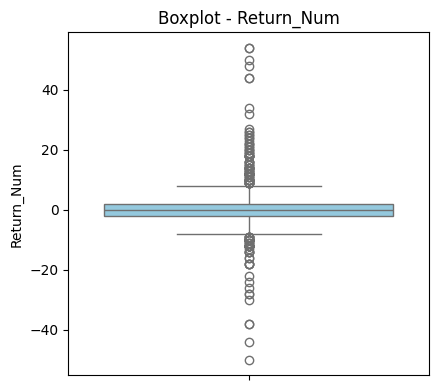

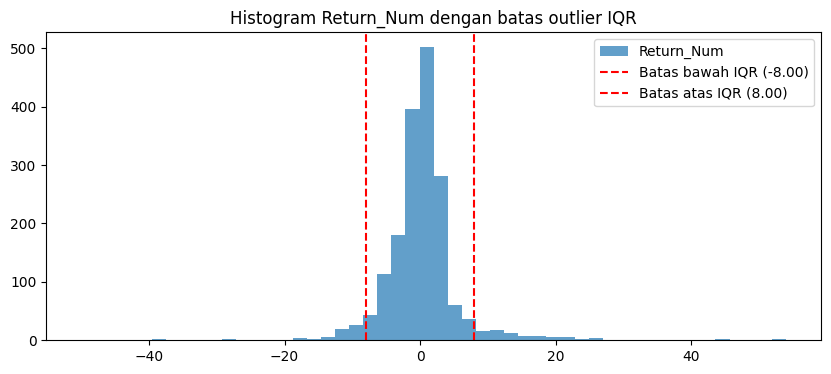

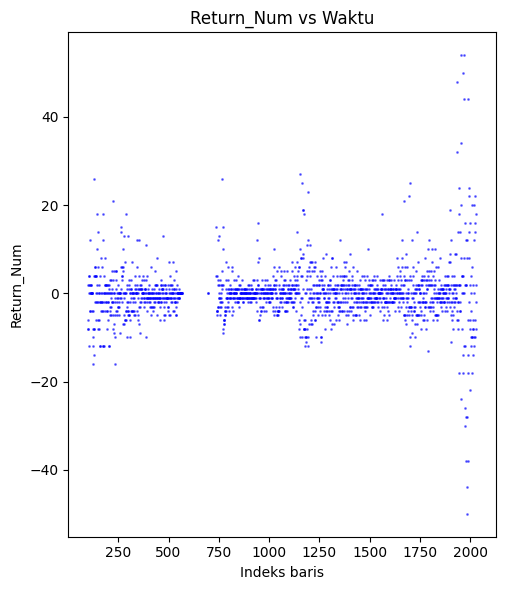

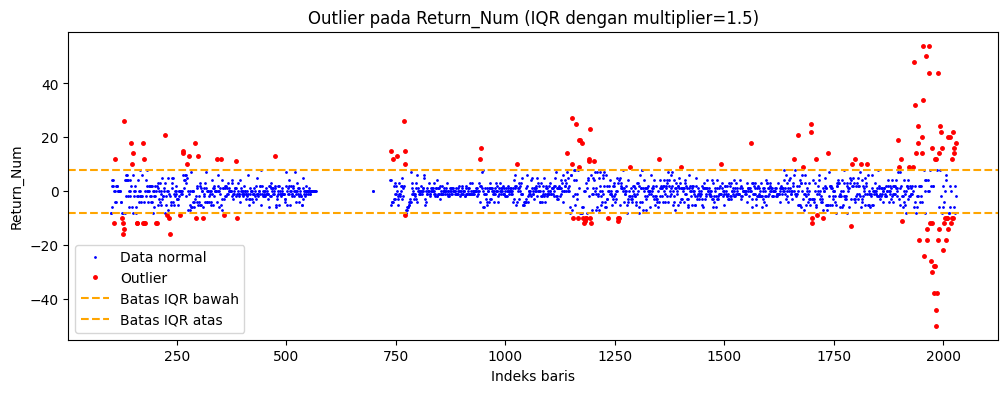

Jumlah outlier pada Return_Num: 153 (8.67% dari data)


In [72]:
selected_columns = ['Return_Num'] 

plt.figure(figsize=(12, 4))
for i, col in enumerate(selected_columns, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot - {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

for col in selected_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    plt.figure(figsize=(10, 4))
    plt.hist(df[col], bins=50, alpha=0.7, label=col)
    plt.axvline(lower_bound, color='red', linestyle='--', label=f'Batas bawah IQR ({lower_bound:.2f})')
    plt.axvline(upper_bound, color='red', linestyle='--', label=f'Batas atas IQR ({upper_bound:.2f})')
    plt.title(f'Histogram {col} dengan batas outlier IQR')
    plt.legend()
    plt.show()

plt.figure(figsize=(14, 6))
for i, col in enumerate(selected_columns, 1):
    plt.subplot(1, 3, i)
    plt.scatter(df.index, df[col], s=1, alpha=0.5, color='blue')
    plt.title(f'{col} vs Waktu')
    plt.xlabel('Indeks baris')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

for col in selected_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    plt.figure(figsize=(12, 4))
    plt.plot(df.index, df[col], 'b.', markersize=2, label='Data normal')
    plt.plot(outliers.index, outliers[col], 'r.', markersize=5, label='Outlier')
    plt.axhline(y=lower, color='orange', linestyle='--', label='Batas IQR bawah')
    plt.axhline(y=upper, color='orange', linestyle='--', label='Batas IQR atas')
    plt.title(f'Outlier pada {col} (IQR dengan multiplier=1.5)')
    plt.xlabel('Indeks baris')
    plt.ylabel(col)
    plt.legend()
    plt.show()
    
    print(f"Jumlah outlier pada {col}: {len(outliers)} ({100*len(outliers)/len(df):.2f}% dari data)")

- Volume dan Close: Jelas tidak memiliki outlier (semua titik berada dalam rentang whisker).

- Return: Nilai minimum -0.10 (-10%) secara matematis berada di bawah batas bawah IQR (-0.05), tetapi pada boxplot terlihat whisker memanjang hingga -0.10. Itu berarti plot yang Anda gunakan mungkin menggunakan whisker yang berbeda (misalnya persentil 5-95, atau tidak menggunakan IQR sama sekali). Atau bisa juga data memang memiliki outlier tipis di ekor kiri, tetapi jumlahnya sangat sedikit.

# Distribution Data

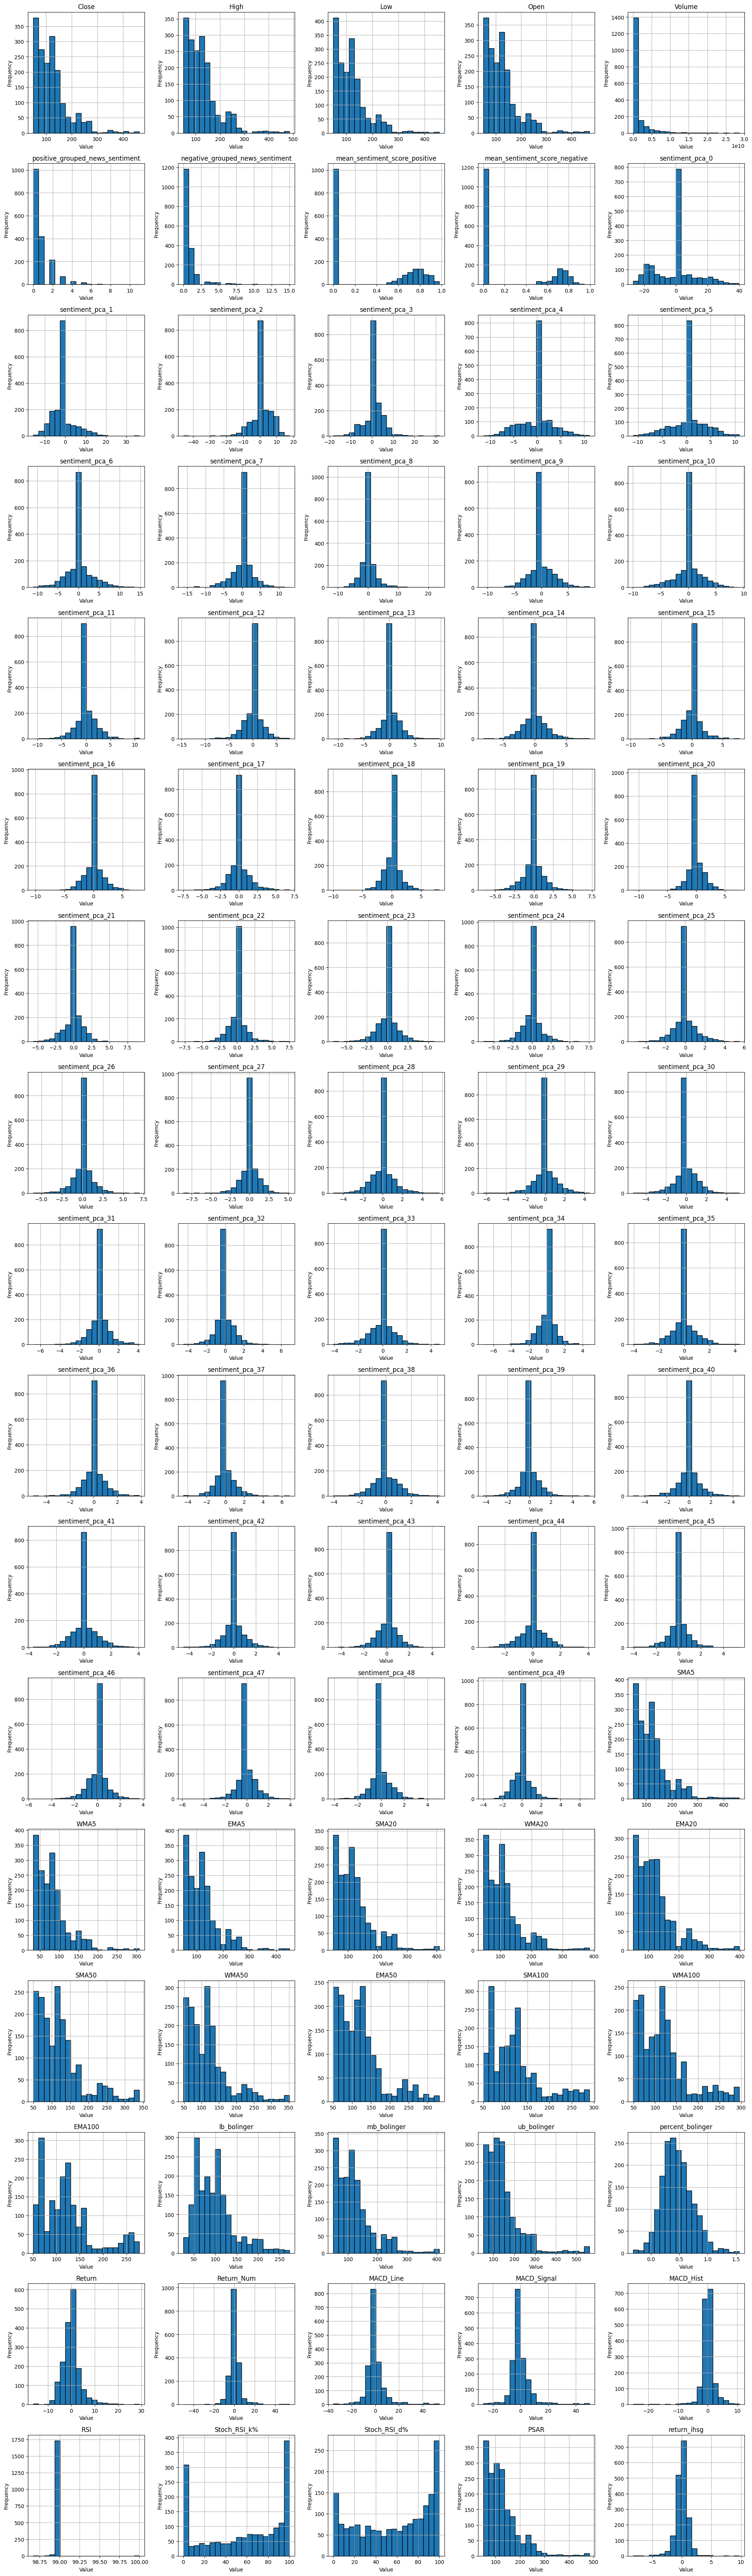

In [73]:
num_vars = df.shape[1]
n_cols = 5
n_rows = -(-num_vars // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, column in enumerate(df.select_dtypes(include=['number']).columns):
    df[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Data Correlation

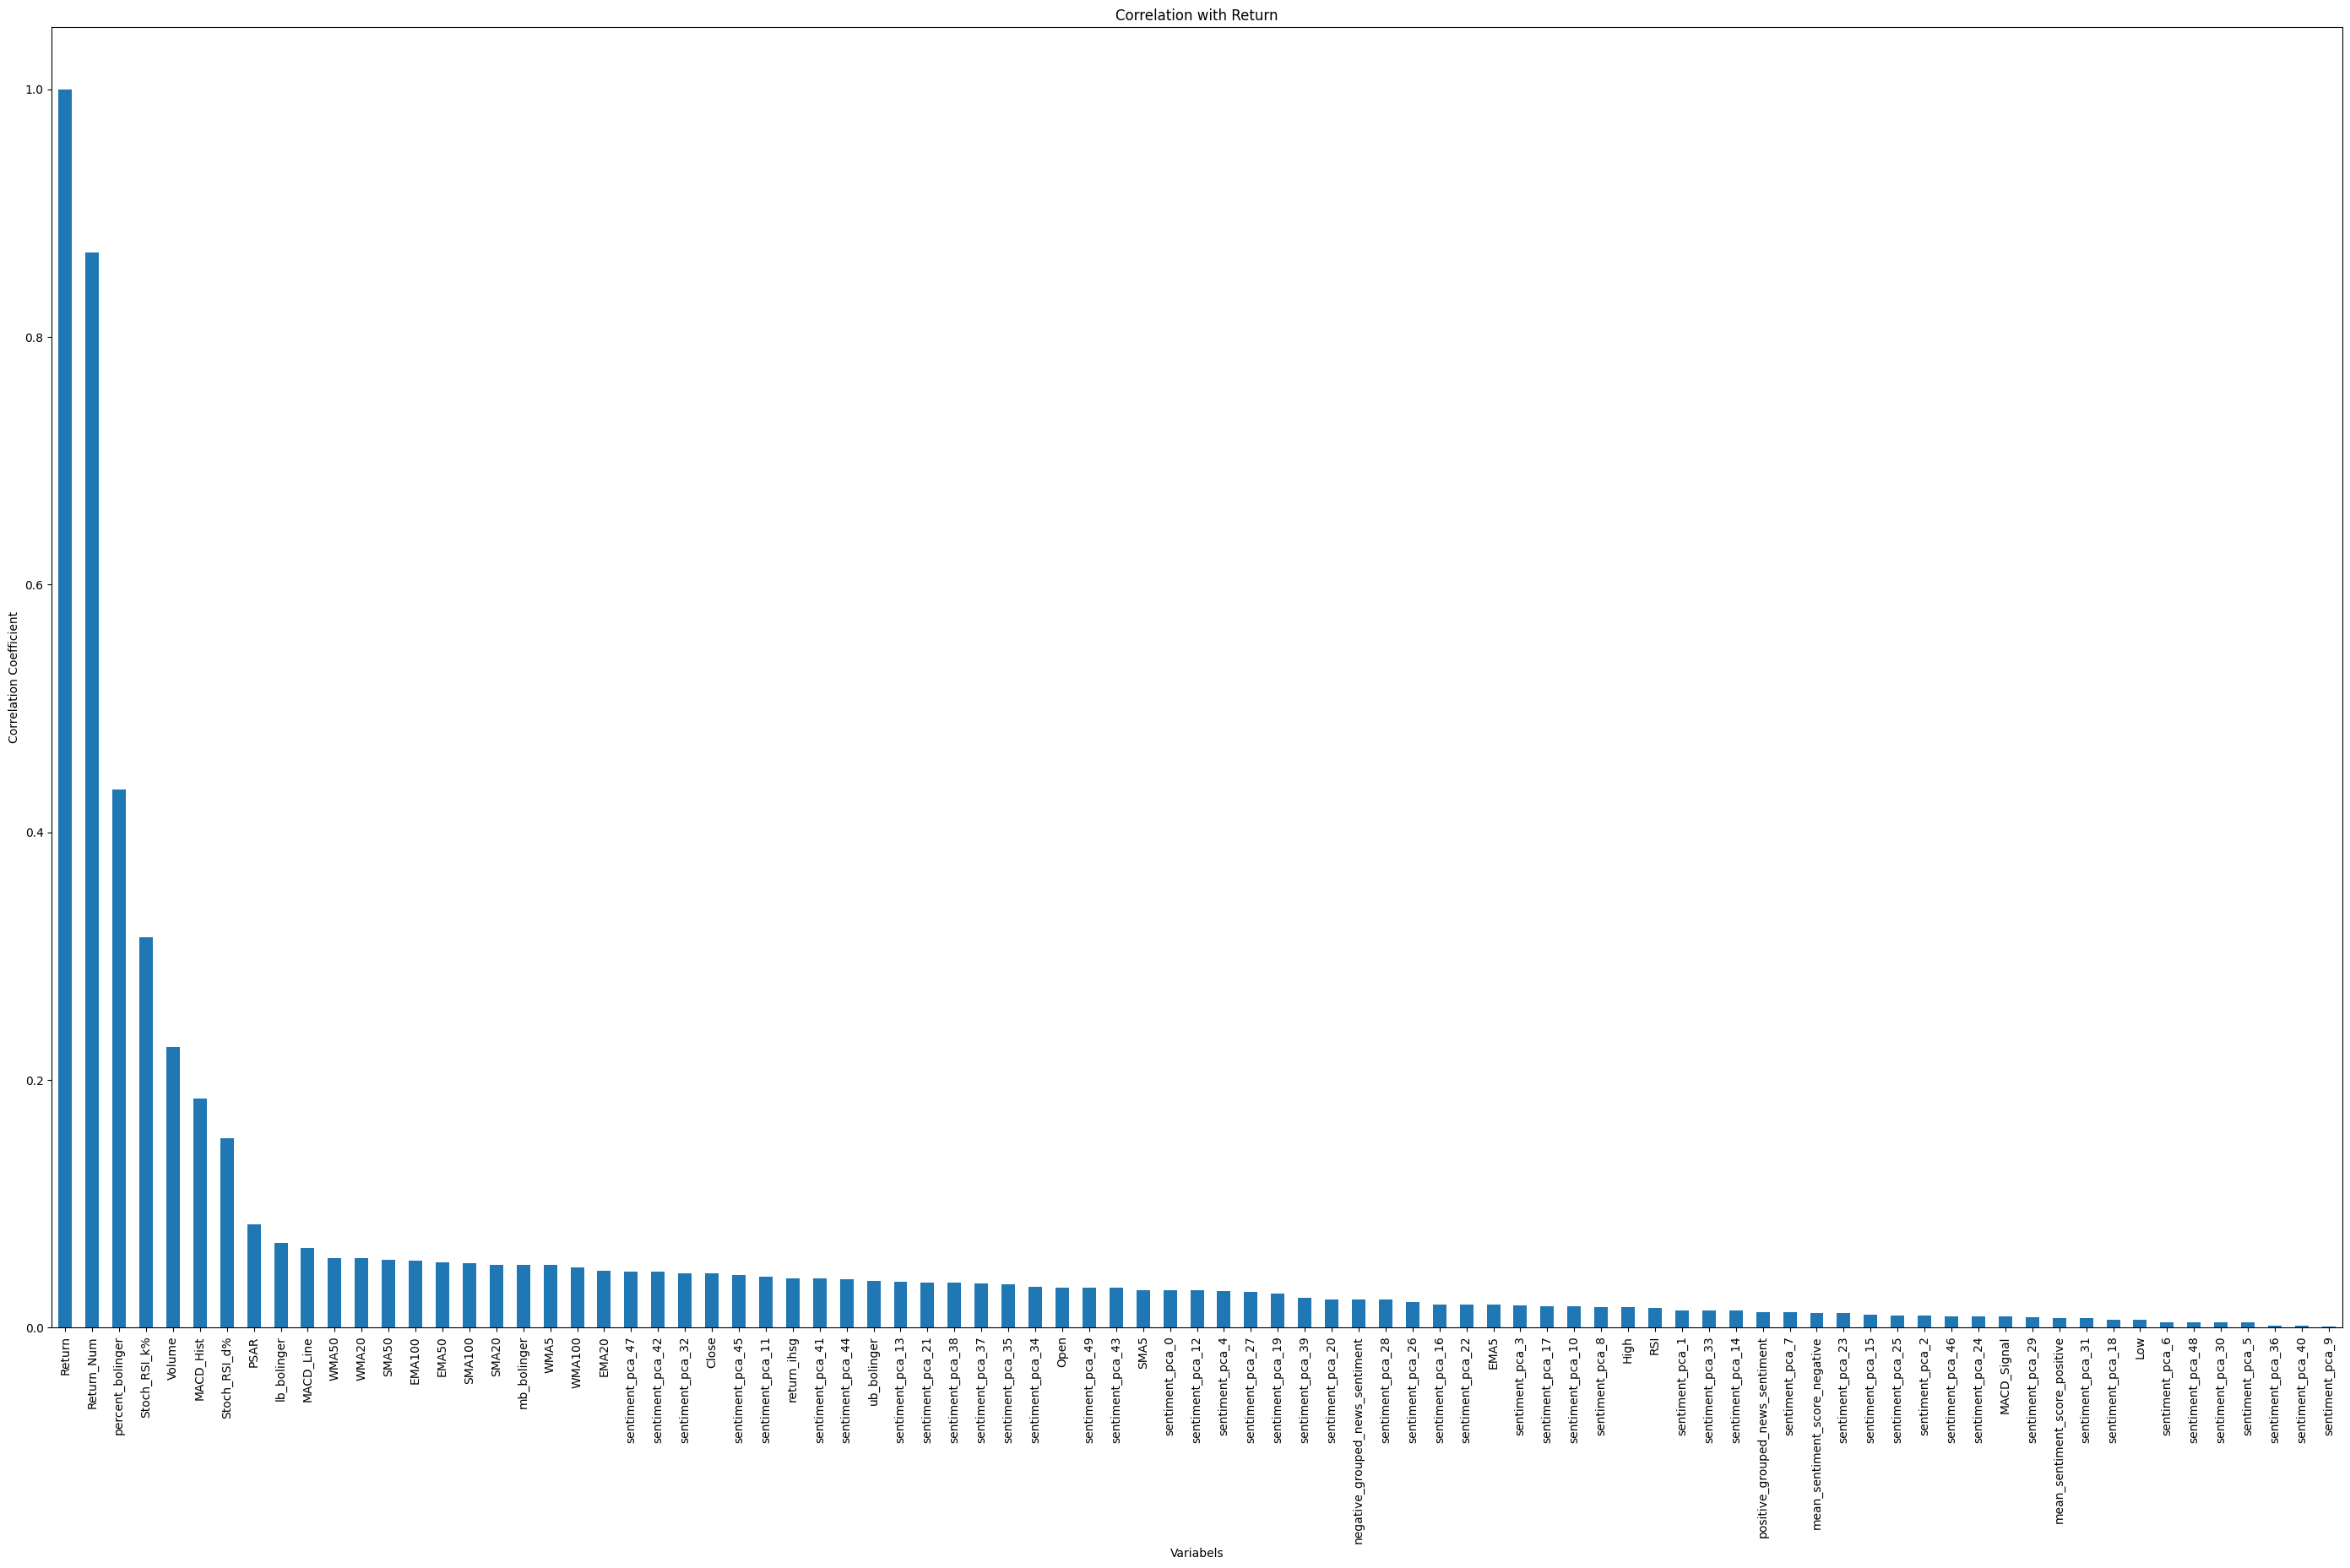

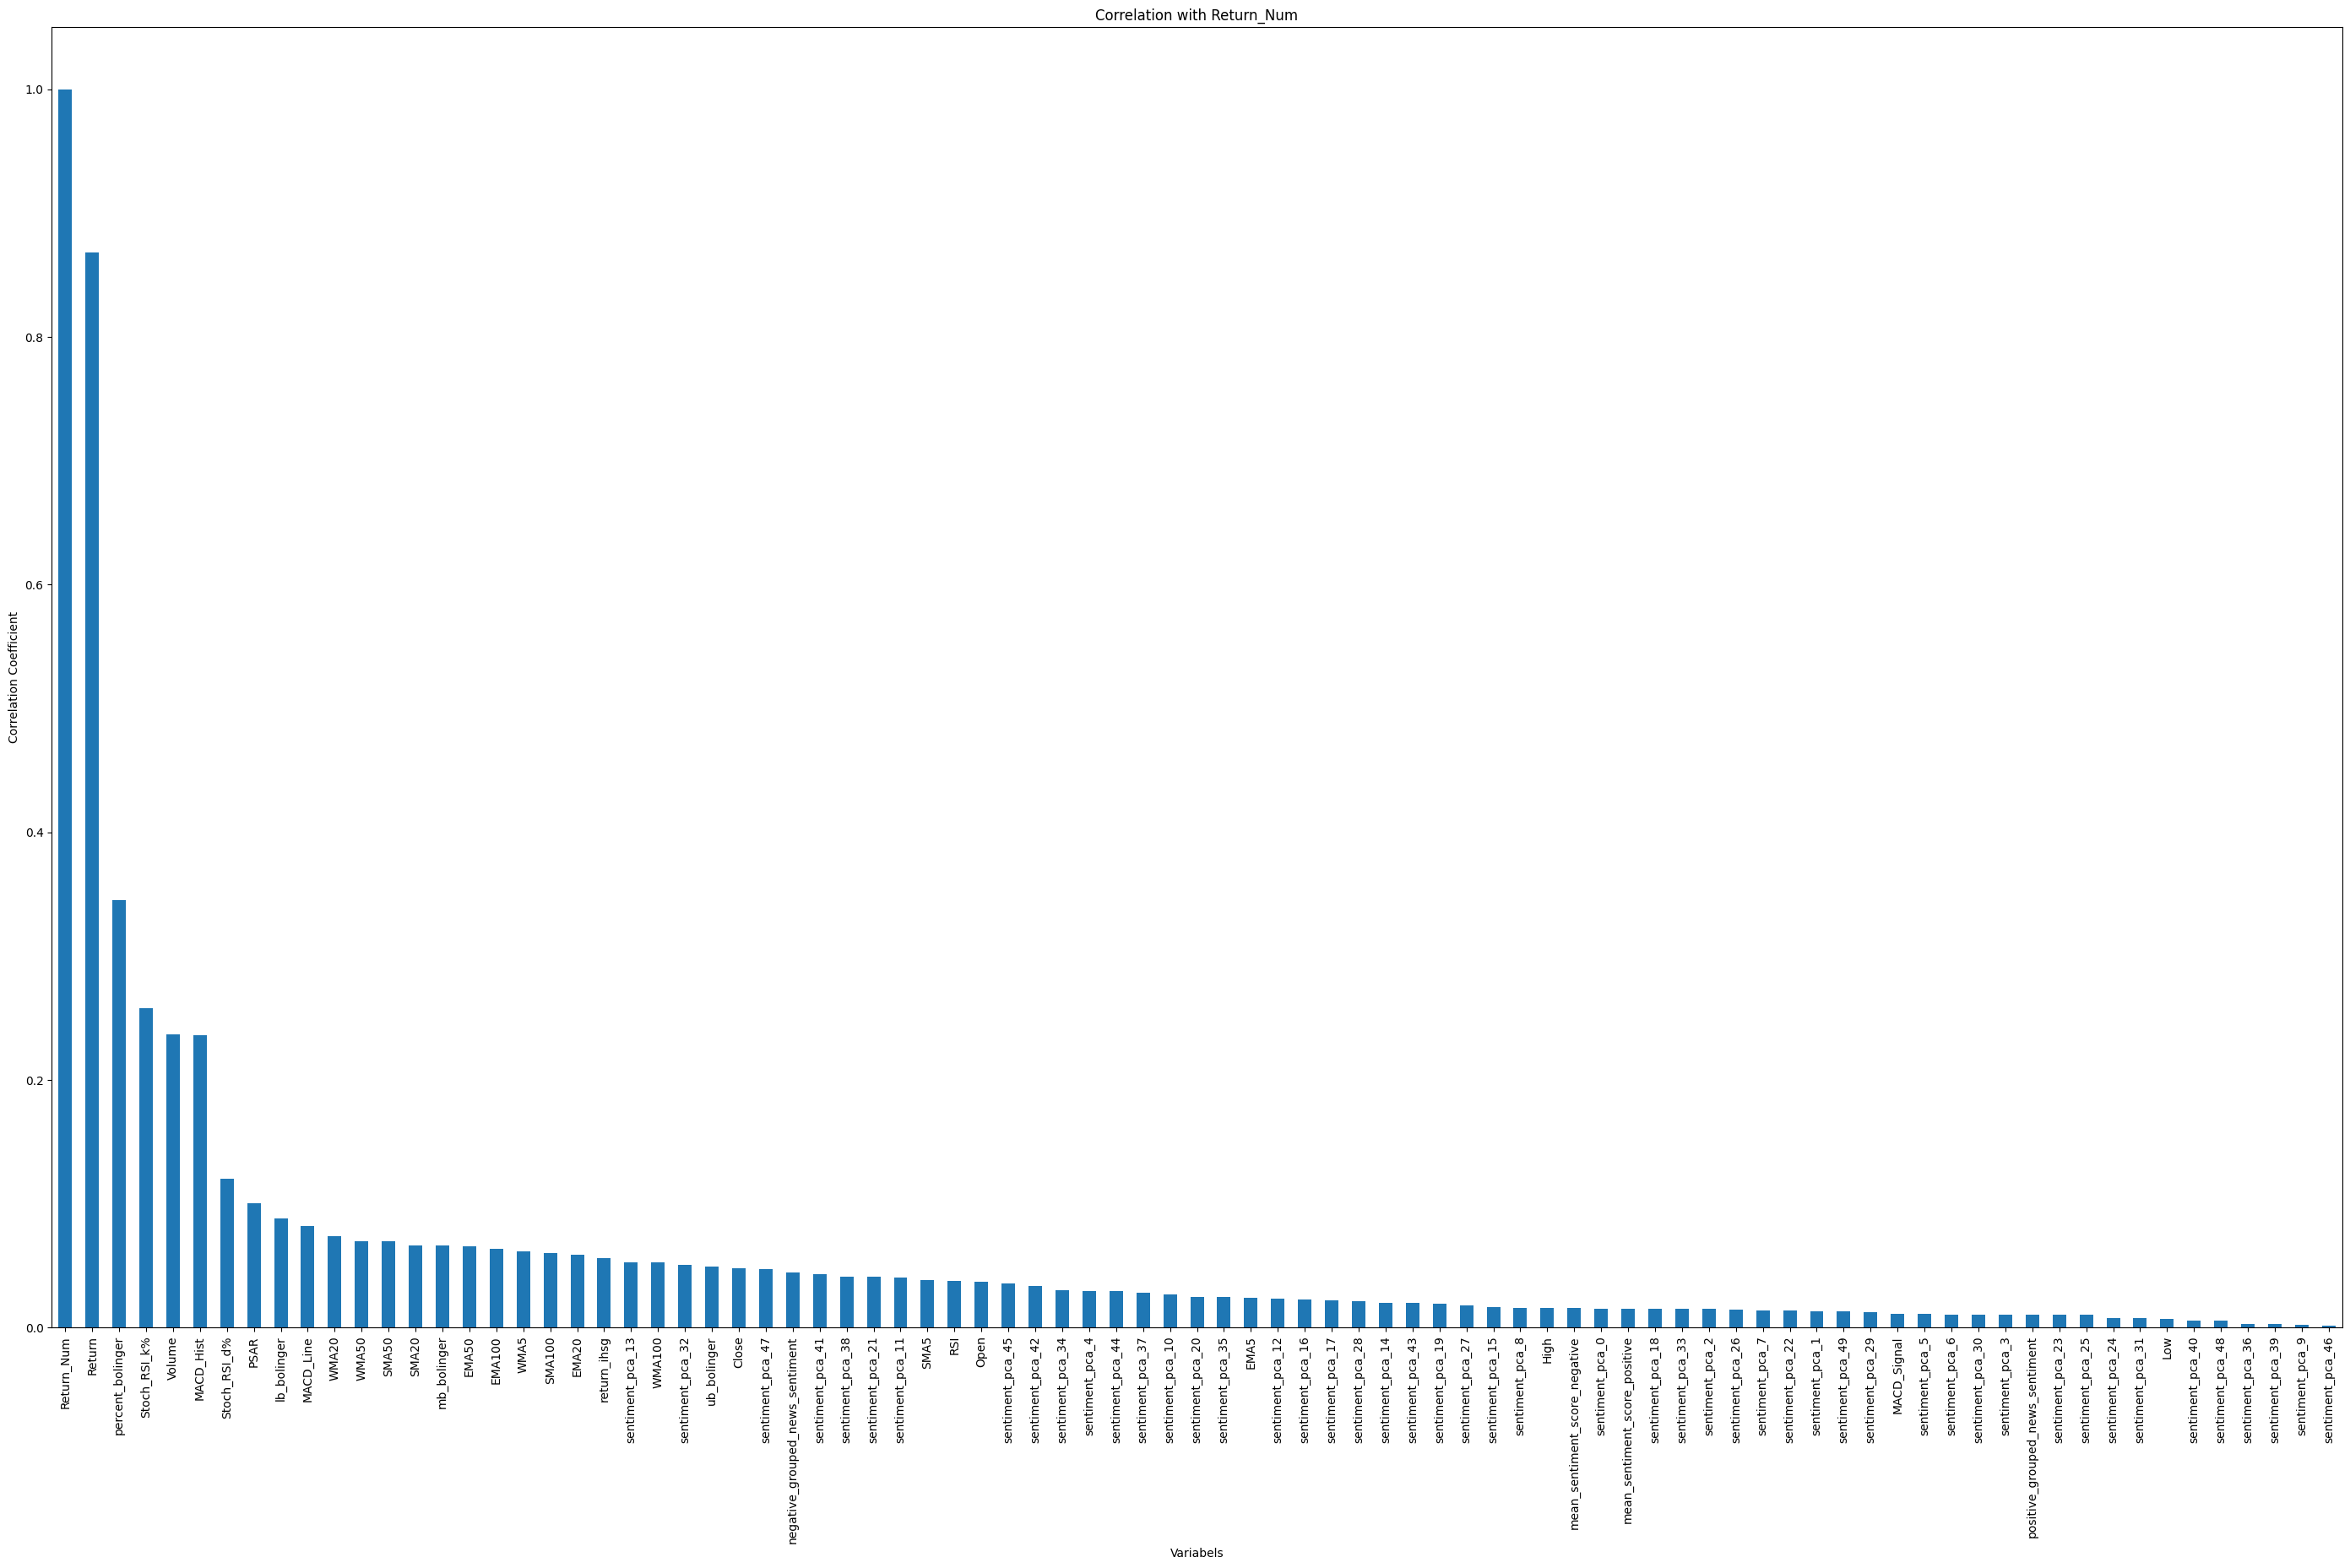

In [80]:
for i in ['Return', 'Return_Num']:
    target_corr = df.select_dtypes(include=['number']).corr()[i]
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)

    plt.figure(figsize=(35, 20))
    target_corr_sorted.plot(kind='bar')
    plt.title(f'Correlation with {i}')
    plt.xlabel('Variabels')
    plt.ylabel('Correlation Coefficient')
plt.show()

## Feature Engineering

In [ ]:
features = df.columns.drop(['Date', 'Return', 'Return_Num'])

X = df[features]

y = df['Return']

In [82]:
X

,Close,High,Low,Open,Volume,positive_grouped_news_sentiment,negative_grouped_news_sentiment,mean_sentiment_score_positive,mean_sentiment_score_negative,sentiment_pca_0,...,ub_bolinger,percent_bolinger,MACD_Line,MACD_Signal,MACD_Hist,RSI,Stoch_RSI_k%,Stoch_RSI_d%,PSAR,return_ihsg
99,266.0,274.0,264.0,274.0,253301700,1.0,1.0,0.822121,0.720498,2.469957,...,292.333022,0.664402,-3.020506,-6.645542,3.625037,98.985140,22.779143,7.593048,233.821600,0.489909
100,258.0,266.0,256.0,266.0,197580600,0.0,4.0,0.000000,0.669386,-8.177450,...,291.579790,0.570369,-2.763132,-5.869060,3.105929,98.987021,44.901218,22.560121,234.705168,1.537435
101,252.0,262.0,252.0,260.0,135997100,2.0,0.0,0.685511,0.000000,-10.057339,...,290.402370,0.500000,-3.008629,-5.296974,2.288345,98.993675,97.340333,55.006898,235.571065,-0.948235
102,254.0,264.0,252.0,252.0,233610000,4.0,0.0,0.715043,0.000000,12.184089,...,288.875753,0.525832,-3.007140,-4.839007,1.831867,98.991718,81.917168,74.719573,236.419643,-0.458010
103,258.0,262.0,252.0,252.0,186291600,1.0,1.0,0.912367,0.764113,-6.772538,...,286.149448,0.574131,-2.652616,-4.401729,1.749113,98.987952,52.235867,77.164456,237.251250,0.520603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025,252.0,254.0,244.0,246.0,7028235400,4.0,15.0,0.669227,0.681975,-18.825335,...,283.296195,0.726891,-7.195108,-13.453842,6.258735,98.985458,0.000000,11.900972,209.548829,-4.192284
2026,244.0,250.0,240.0,248.0,3231004700,3.0,4.0,0.737894,0.741672,-10.857300,...,282.824116,0.655351,-5.756309,-11.914336,6.158027,98.985458,0.000000,11.900972,213.104923,-1.719456
2027,246.0,254.0,246.0,246.0,3723636000,2.0,3.0,0.802816,0.784027,-0.247363,...,282.911068,0.671089,-4.403902,-10.412249,6.008347,98.982786,0.000000,0.000000,216.376529,-4.286264
2028,244.0,250.0,240.0,242.0,2492525700,1.0,3.0,0.588216,0.722465,-15.282110,...,282.335791,0.650449,-3.453681,-9.020536,5.566854,98.981324,0.000000,0.000000,219.386407,-4.620556


In [83]:
y

99     -2.963180
100    -3.053672
101    -2.353050
102     0.790518
103     1.562532
          ...   
2025    6.559728
2026   -3.226086
2027    0.816331
2028   -0.816331
2029    7.117628
Name: Return, Length: 1764, dtype: float64

Hitung korelasi Pearson antara setiap fitur dan target. Pilih fitur yang nilai absolut korelasinya > 0.1.

- Mengapa threshold 0.3? Karena di bawah itu, hubungan linear sangat lemah fitur seperti Volume_Change biasanya di bawah 0.1 dan cenderung hanya menambah noise.

- Catatan: Korelasi linear tidak menangkap hubungan non-linear, tetapi untuk langkah awal penyaringan cukup baik. Model CNN-LSTM nanti bisa menangkap pola non-linear dari fitur yang tersisa.

## Data Normalization

In [ ]:
scaler_X = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)

# Data Splitting

In [ ]:
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# Data Training

In [ ]:
model = Sequential()

model.add(Dense(
    64,
    activation='relu',
    input_dim=X_train.shape[1]
))

model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    16,
    activation='relu'
))

model.add(Dense(1))

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1
)

# Data Evaluation

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

In [ ]:
direction_acc = np.mean(
    np.sign(predictions.flatten()) ==
    np.sign(y_test.values)
)

print(direction_acc)

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label='Actual Return'
)

plt.plot(
    predictions,
    label='Predicted Return'
)

plt.legend()

plt.show()

# Result

In [ ]:
# Misal df sudah berisi data historis hingga hari ini (setelah feature engineering)
last_data = df.iloc[-LOOKBACK:]  # ambil LOOKBACK baris terakhir
X_last = last_data[selected_features].values  # selected_features adalah fitur yang digunakan saat training
X_last_scaled = scaler_X.transform(X_last)    # normalisasi
X_last_seq = X_last_scaled.reshape(1, LOOKBACK, len(selected_features))  # bentuk (1, lookback, n_features)

pred_scaled = model.predict(X_last_seq)   # output skala normalisasi (0-1)
pred = scaler_y.inverse_transform(pred_scaled)  # konversi ke harga asli (atau return)
print(f"Prediksi harga besok: {pred[0,0]:.2f}")

In [ ]:
import joblib
from tensorflow.keras.models import save_model

# --- 1. Simpan Model LSTM ---
# Gunakan format .keras untuk menyimpan arsitektur, bobot, dan konfigurasi training.
model.save('model_saham_lstm.keras')
print("Model LSTM berhasil disimpan.")

# --- 2. Simpan Scaler dan Fitur Lainnya dengan Joblib ---
# Scaler untuk fitur input (X)
joblib.dump(scaler_X, 'scaler_X.joblib')
# Scaler untuk target (y)
joblib.dump(scaler_y, 'scaler_y.joblib')
# Daftar nama fitur yang terpilih
joblib.dump(selected_features, 'selected_features.joblib')

print("Scaler dan konfigurasi berhasil disimpan.")